# Practice 3: Sentiment Analysis with Hugging Face Transformers

This notebook presents an end-to-end binary sentiment-classification workflow on the Rotten Tomatoes dataset. Core processing stays in `processing_own_phase/*.py`; the notebook calls those modules and presents verified results.

## Phase 0 - Problem Definition

### Objective

Build and verify a DistilBERT classifier that maps an English movie review to `NEGATIVE` or `POSITIVE`.

| Item | Definition |
|---|---|
| Input | English movie-review text |
| Output | `0 = NEGATIVE`, `1 = POSITIVE` |
| Dataset | Rotten Tomatoes: 8,530 Train / 1,066 Validation / 1,066 Test |
| Model | `distilbert/distilbert-base-uncased` |
| Metrics | Loss, Accuracy, Precision, Recall and F1 |
| Selection rule | Lowest Validation loss; Test is used once after checkpoint selection |

### Success Criteria

- Dataset, labels, tokenization and preprocessing pass sanity checks.
- Fine-tuning uses Train; checkpoint selection uses Validation only.
- The locked checkpoint is evaluated once on Test.
- Saved model and tokenizer reload with equivalent predictions.

### Workflow

![Practice 3 workflow](../docs/result/phase_00_pipeline_uml.png)

The workflow keeps model selection on Validation and uses Test only for the locked model's final evaluation.

## Phase 1 Environment & Reproducibility

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root added: {project_root}") 

Project root added: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3


In [2]:
# Phase 1: Environment & Reproducibility
from processing_own_phase.phase_01_environment import (
    set_seed,
    print_environment_info,
    save_environment_report,
)

# Set seed (must be done before running anything else)
set_seed(42)

# Print full report and save JSON file
info = print_environment_info()
filepath = save_environment_report(info)

# Quick summary
print(f"\nReport saved: {filepath}")
print(f"Device: {info['device']}")
print(f"Seed: {info['seed']}")


ENVIRONMENT INFORMATION
Timestamp: 2026-08-14T14:16:29.351048
Python Version: 3.11.14
Device: mps
Global Seed: 42

--- Package Versions ---
[OK     ] transformers    installed: 5.14.1       required: 5.14.1
[OK     ] datasets        installed: 5.0.1        required: 5.0.1
[OK     ] evaluate        installed: 0.4.6        required: 0.4.6
[OK     ] accelerate      installed: 1.14.0       required: 1.14.0
[OK     ] torch           installed: 2.13.0       required: 2.13.0
[OK     ] numpy           installed: 2.4.6        required: 2.4.6
[OK     ] matplotlib      installed: 3.11.1       required: 3.11.1
[OK     ] pandas          installed: 3.0.5        required: 3.0.5
[OK     ] scikit-learn    installed: 1.9.0        required: 1.9.0

--- Hugging Face Connectivity ---
Status: ok
  Checkpoint: distilbert-base-uncased
  Vocab size: 30522

Environment report saved to: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/docs/result/2026-08-10_phase01-envir

# Phase 2: Pretrained Sentiment Inference

In [ ]:
from processing_own_phase.phase_02_pretrained_inference import (
    get_sentiment_pipeline,
    run_inference,
    inspect_tokenizer
)

# Load pipeline (first time downloads ~260MB model, requires internet)
pipe = get_sentiment_pipeline()

# 3 sample sentences
test_sentences = [
    "I absolutely loved this movie! The performances were outstanding.",
    "This film was a complete waste of time. Terrible acting.",
    "It was okay, nothing special."
]

# Run inference
results = run_inference(pipe, test_sentences)
for sentence, result in zip(test_sentences, results):
    print(f"Sentence: {sentence[:60]}...")
    print(f"  Label: {result['label']}, Score: {result['score']:.4f}\n")

# Inspect tokenizer
token_info = inspect_tokenizer(test_sentences[0])
print("Tokenizer vocab size:", token_info['vocab_size'])
print("Tokens (first 20):", token_info['tokens'][:20])

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sentence: I absolutely loved this movie! The performances were outstan...
  Label: POSITIVE, Score: 0.9999

Sentence: This film was a complete waste of time. Terrible acting....
  Label: NEGATIVE, Score: 0.9998

Sentence: It was okay, nothing special....
  Label: NEGATIVE, Score: 0.9821

Tokenizer vocab size: 30522
Tokens (first 20): ['[CLS]', 'i', 'absolutely', 'loved', 'this', 'movie', '!', 'the', 'performances', 'were', 'outstanding', '.', '[SEP]']


# Phase 3: Tokenization Investigation

In [4]:
# Phase 3: Tokenization Investigation
from processing_own_phase.phase_03_tokenization import (
    tokenize_sentence_to_table,
    print_tokenized_table,
    decode_sanity_check,
    compare_tokenizers,
)

sentence = "I absolutely loved this movie! The performances were outstanding."
print(f"Raw sentence: {sentence}\n")

# Display the implementation's readable token table (tokens + token IDs).
token_table = tokenize_sentence_to_table(sentence)
print_tokenized_table(token_table)

# Display the attention mask produced by the same tokenizer comparison.
comparison = compare_tokenizers(sentence)
print(f"\nToken IDs: {comparison['finetuned']['input_ids']}")
print(f"Attention mask: {comparison['finetuned']['attention_mask']}")

# Verify that decoding preserves the sentence meaning.
decode_result = decode_sanity_check(sentence)
print(f"\nDecoded text: {decode_result['decoded_sentence']}")
print(f"Word overlap ratio: {decode_result['word_overlap_ratio']}")
print(f"Decode sanity check: {'PASS' if decode_result['semantically_consistent'] else 'FAIL'}")
assert decode_result['semantically_consistent'], "Decode sanity check failed"

result = comparison

# Print conclusion
print(f"Are tokenizers identical? {result['are_identical']}")
print(f"\nVocab size (fine-tuned): {result['finetuned']['vocab_size']}")
print(f"Vocab size (base): {result['base']['vocab_size']}")

if result['are_identical']:
    print("\nCONCLUSION: The tokenizers from the fine-tuned model and the base model are IDENTICAL.")
    print("  -> Fine-tuning only updates the backbone model weights.")
    print("  -> The tokenizer remains unchanged, vocab_size = 30522.")
    print("  -> This confirms that the tokenizer does not change during fine-tuning.")
else:
    print("\nCONCLUSION: Tokenizers are different (unexpected).")

Raw sentence: I absolutely loved this movie! The performances were outstanding.

Position  Token               Token ID    Special?  
----------------------------------------------------
0         [CLS]               101         Yes       
1         i                   1045        No        
2         absolutely          7078        No        
3         loved               3866        No        
4         this                2023        No        
5         movie               3185        No        
6         !                   999         No        
7         the                 1996        No        
8         performances        4616        No        
9         were                2020        No        
10        outstanding         5151        No        
11        .                   1012        No        
12        [SEP]               102         Yes       

Token IDs: [101, 1045, 7078, 3866, 2023, 3185, 999, 1996, 4616, 2020, 5151, 1012, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1

# Phase 4: Dataset Loading

In [17]:
# Phase 4: Dataset Loading
from processing_own_phase.phase_04_dataset_loading import (
    load_rotten_tomatoes,
    verify_dataset_contract,
    get_dataset_stats,
    check_null_values,
    print_sample_rows,
    save_dataset_summary,
)

# Load dataset
dataset = load_rotten_tomatoes()
print(f"Dataset loaded! Splits: {list(dataset.keys())}")

# Verify all required splits, sizes, schema and every label.
dataset_contract = verify_dataset_contract(dataset)
assert dataset_contract['all_pass'], "Phase 4 dataset contract failed"
print("\nPhase 4 verification:")
print(f"  Splits exist: {dataset_contract['splits_exist']}")
print(f"  Split sizes: {dataset_contract['split_sizes']}")
print(f"  Schema: {dataset_contract['schema']}")
print(f"  Label sets: {dataset_contract['label_sets']}")

# Get statistics
stats = get_dataset_stats(dataset)
print("\nDataset Statistics:")
for split_name, split_stats in stats.items():
    print(f"\n{split_name.capitalize()}:")
    print(f"  Total: {split_stats['total']}")
    print(f"  Positive: {split_stats['positive']} ({split_stats['positive_pct']:.1f}%)")
    print(f"  Negative: {split_stats['negative']} ({split_stats['negative_pct']:.1f}%)")

# Check null values
null_report = check_null_values(dataset)
print("\nNull Values Check:")
all_clean = True
for split_name, null_counts in null_report.items():
    for col, count in null_counts.items():
        if count > 0:
            print(f"  {split_name}.{col}: {count} null values")
            all_clean = False
        else:
            print(f"  {split_name}.{col}: No null values")

if all_clean:
    print("\nDataset is clean! No null values found.")

dataset_summary = {
    'contract': dataset_contract,
    'statistics': stats,
    'null_report': null_report,
}
dataset_summary_path = save_dataset_summary(dataset_summary)
print(f"Phase 4 verification: PASS")
print(f"Dataset summary saved: {dataset_summary_path}")

# Print sample rows
print_sample_rows(dataset, "train", 3)

Dataset loaded! Splits: ['train', 'validation', 'test']

Phase 4 verification:
  Splits exist: True
  Split sizes: {'train': 8530, 'validation': 1066, 'test': 1066}
  Schema: {'train': {'columns': ['label', 'text'], 'has_text': True, 'has_label': True}, 'validation': {'columns': ['label', 'text'], 'has_text': True, 'has_label': True}, 'test': {'columns': ['label', 'text'], 'has_text': True, 'has_label': True}}
  Label sets: {'train': [0, 1], 'validation': [0, 1], 'test': [0, 1]}

Dataset Statistics:

Train:
  Total: 8530
  Positive: 4265 (50.0%)
  Negative: 4265 (50.0%)

Validation:
  Total: 1066
  Positive: 533 (50.0%)
  Negative: 533 (50.0%)

Test:
  Total: 1066
  Positive: 533 (50.0%)
  Negative: 533 (50.0%)

Null Values Check:
  train.text: No null values
  train.label: No null values
  validation.text: No null values
  validation.label: No null values
  test.text: No null values
  test.label: No null values

Dataset is clean! No null values found.
Phase 4 verification: PASS
Datase

# Phase 5: EDA and Sanity Checks

Histogram saved to: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/docs/result/phase_05_token_length_distribution.png


### 5.1 Dataset Schema and 5.2 Text Quality

,split,schema_pass,null_text,empty_string,whitespace_only
0,train,True,0,0,0
1,validation,True,0,0,0
2,test,True,0,0,0


### 5.3 Label Distribution

,split,total,positive,negative,positive_pct,negative_pct
0,train,8530,4265,4265,50.0,50.0
1,validation,1066,533,533,50.0,50.0
2,test,1066,533,533,50.0,50.0


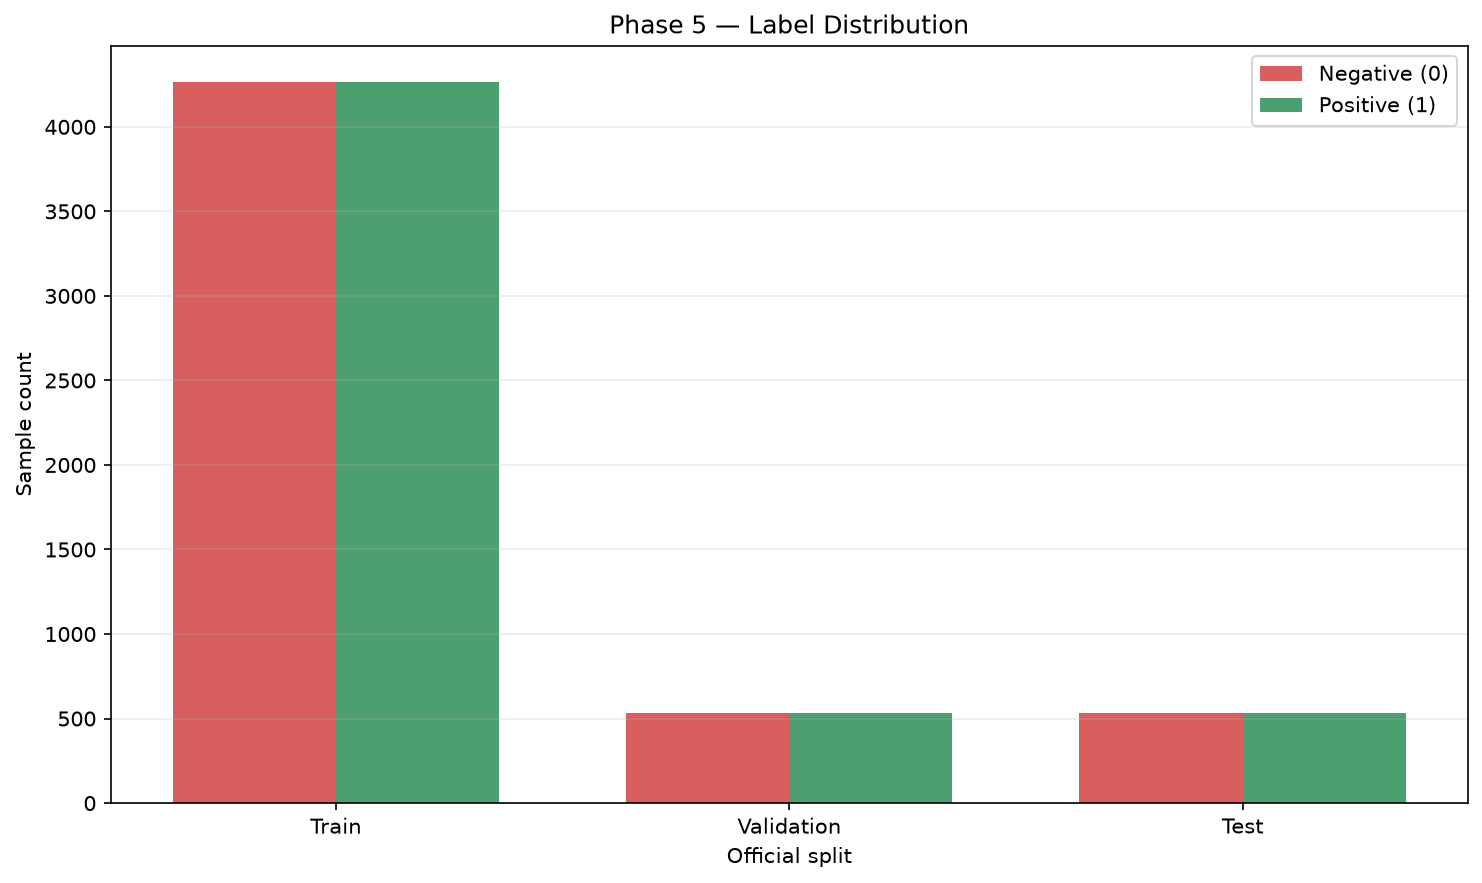

### 5.4 Duplicate and Leakage Analysis

,scope,check,count
0,train,within-split exact duplicates,0
1,validation,within-split exact duplicates,0
2,test,within-split exact duplicates,0
3,train<->validation,cross-split exact overlap,0
4,train<->test,cross-split exact overlap,0
5,validation<->test,cross-split exact overlap,0


### 5.5–5.6 Text Length Statistics and Visualizations

,split,measure,min,max,mean,median,p95,p99
0,train,character,4.0,267.0,113.971630,111.0,204.0,241.00
1,train,word,1.0,59.0,20.992849,20.0,37.0,45.00
2,train,token,3.0,78.0,27.368347,27.0,47.0,56.00
3,validation,character,6.0,263.0,114.295497,112.0,211.0,243.35
4,validation,word,1.0,54.0,20.997186,21.0,38.0,46.00
5,validation,token,4.0,72.0,27.322702,27.0,49.0,55.00
6,test,character,14.0,261.0,115.523452,113.0,206.0,245.00
7,test,word,3.0,52.0,21.220450,20.0,38.0,45.00
8,test,token,5.0,67.0,27.662289,27.0,48.0,57.00


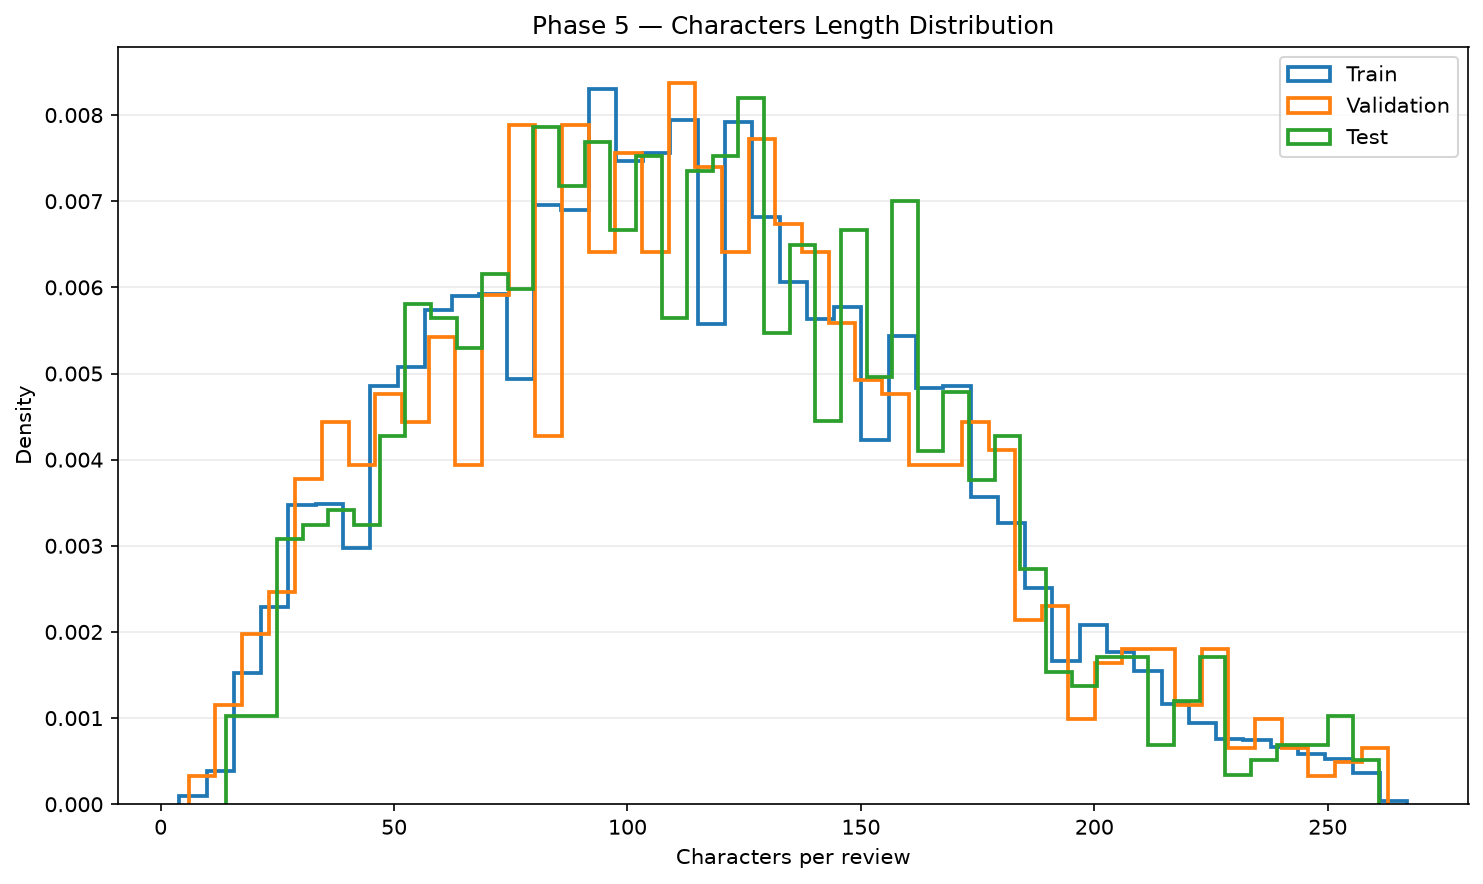

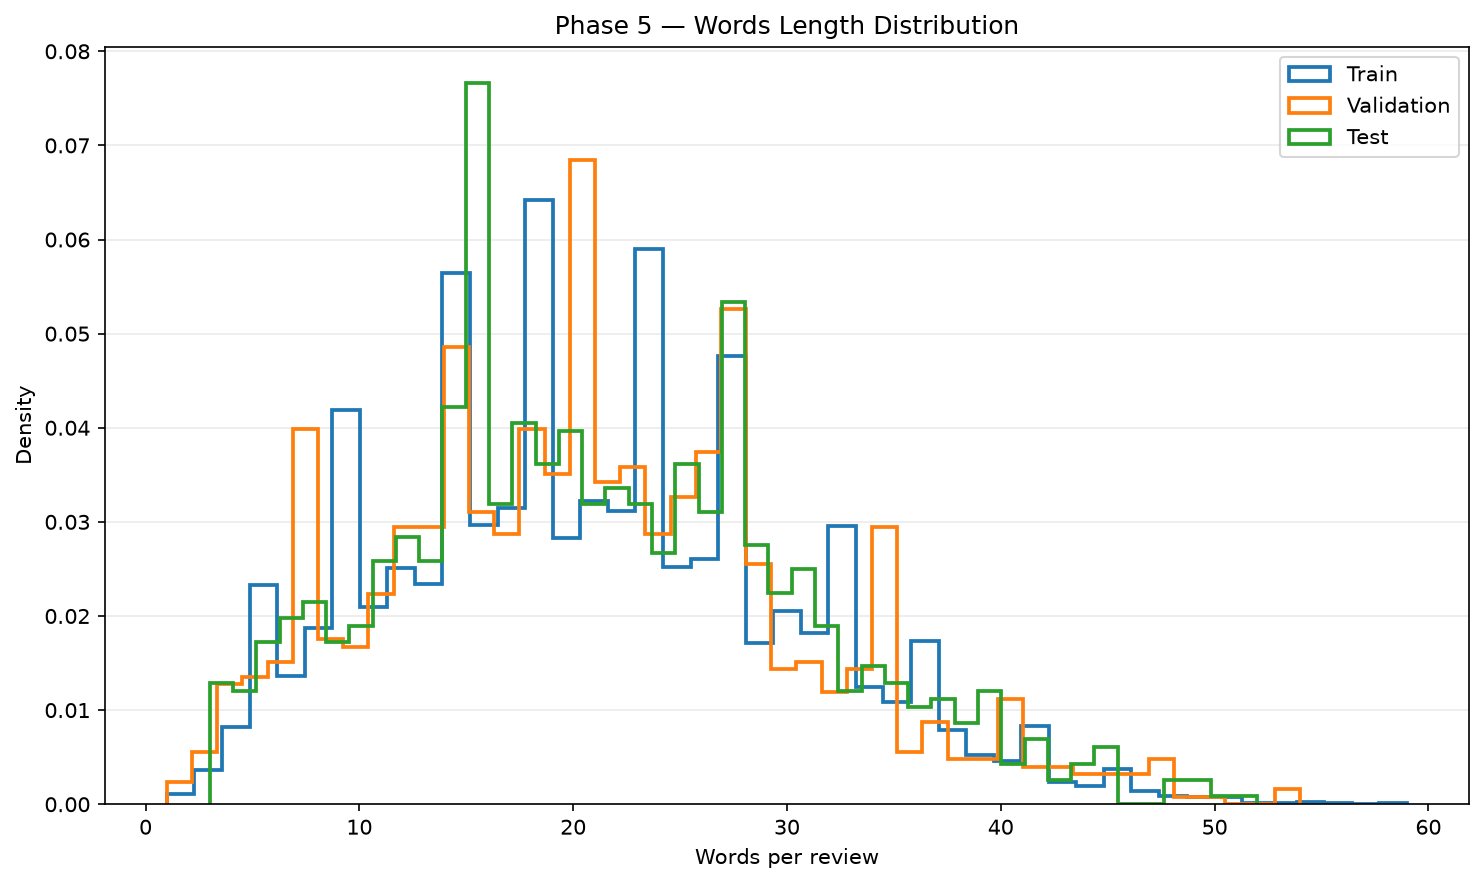

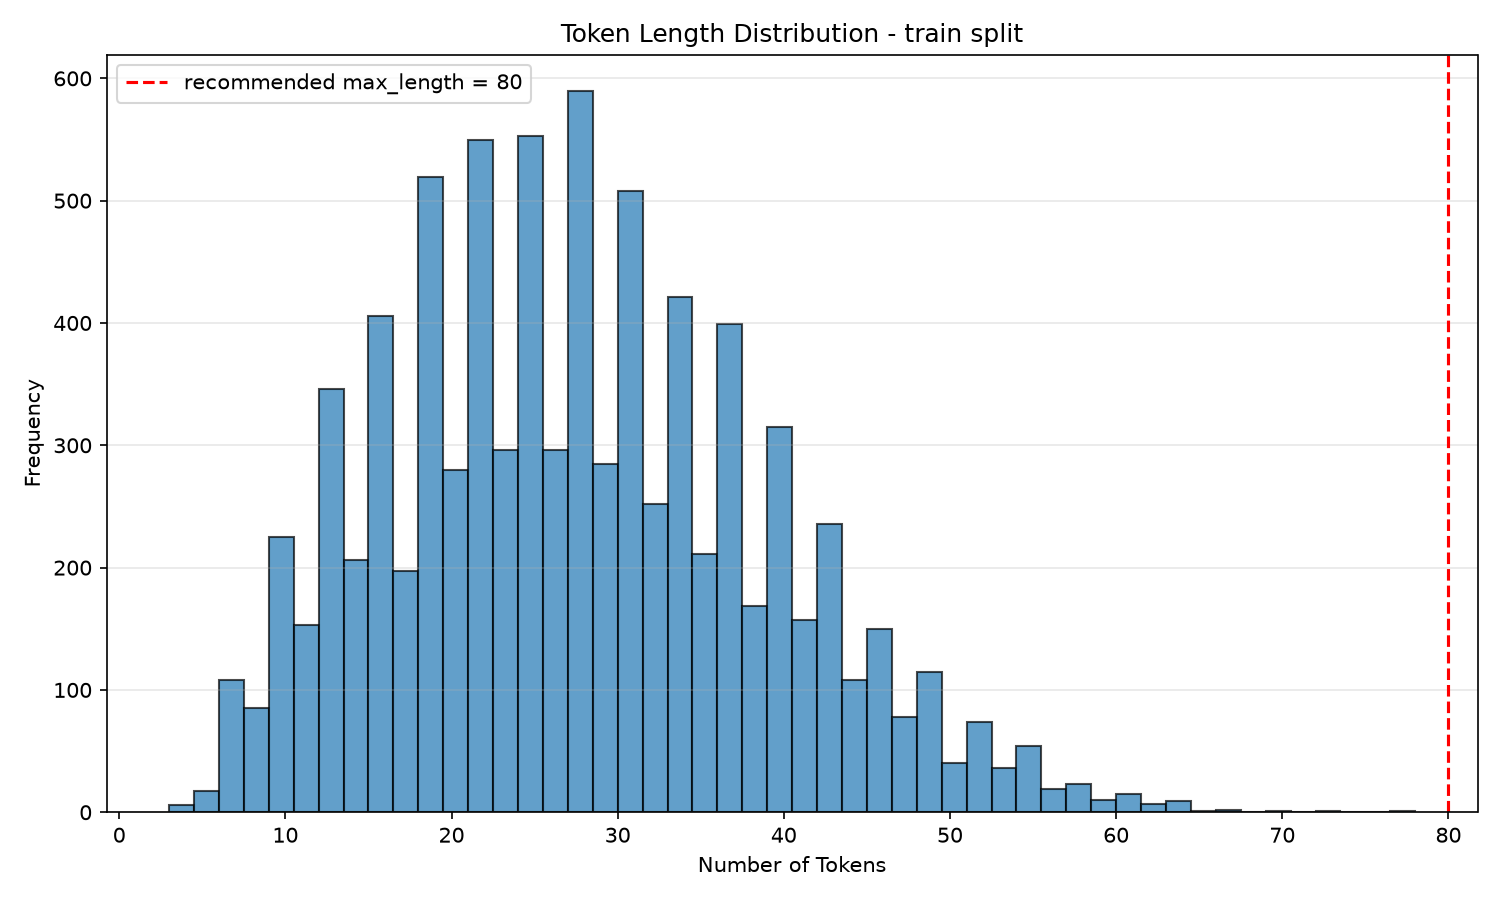

### 5.7 Deterministic Representative Samples

,split,index,label,label_name,character_count,word_count,token_count,text
0,train,4265,0,Negative,32,6,11,"simplistic , silly and tedious ."
1,train,4266,0,Negative,79,15,21,"it's so laddish and juvenile , only teenage bo..."
2,train,4267,0,Negative,137,22,29,exploitative and largely devoid of the depth o...
3,train,0,1,Positive,177,34,47,the rock is destined to be the 21st century's ...
4,train,1,1,Positive,226,39,52,"the gorgeously elaborate continuation of "" the..."
5,train,2,1,Positive,30,4,10,effective but too-tepid biopic


Selection rule: first three indexed Train examples for each label; no score- or narrative-based cherry-picking.

### 5.8 Extreme Samples

**Shortest reviews by token count**

...

,split,samples,samples_over_max_length,percentage_over_max_length,observed_max
0,train,8530,0,0.0,78
1,validation,1066,0,0.0,72
2,test,1066,0,0.0,67


Observed Train token distribution → P95=47, P99=56, maximum=78  
→ selected `MAX_TOKEN_LENGTH=80` → expected observed-split truncation shown above.

### 5.10 EDA Conclusion

,balanced,missing_text_found,duplicate_or_overlap_found,truncation_risk_at_selected_length,phase_06_decision
0,True,False,False,False,"Tokenize with truncation=True, padding=False, ..."


EDA summary saved: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/docs/result/phase_05_eda_summary.json
Token-length statistics saved: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/docs/result/phase_05_token_length_statistics.json
Phase 5 EDA verification: PASS


In [18]:
# Phase 5: EDA and Sanity Checks
import pandas as pd
from IPython.display import Image, Markdown, display
from processing_own_phase.phase_05_dataset_eda import (
    build_eda_summary,
    create_eda_figures,
    save_eda_summary,
    save_token_length_statistics,
)
from processing_own_phase.phase_06_preprocessing import get_tokenizer
from processing_own_phase.config import MAX_TOKEN_LENGTH

tokenizer = get_tokenizer()
eda_summary = build_eda_summary(dataset, tokenizer, MAX_TOKEN_LENGTH)
assert eda_summary['all_pass'], "Phase 5 EDA sanity checks failed"
recommendation = eda_summary['token_length_recommendation']
assert MAX_TOKEN_LENGTH >= recommendation['max']
eda_summary['selected_max_length'] = MAX_TOKEN_LENGTH
eda_summary['max_length_justification'] = (
    f"P95={recommendation['p95']:.0f}, P99={recommendation['p99']:.0f}, "
    f"observed max={recommendation['max']:.0f}; selected {MAX_TOKEN_LENGTH} "
    "is the smallest convenient rounded value above the observed maximum."
)
eda_summary['eda_conclusion'] = {
    'balanced': all(abs(row['positive_pct'] - 50.0) < 1e-12 for row in eda_summary['label_distribution'].values()),
    'missing_text_found': any(sum(row.values()) > 0 for row in eda_summary['text_quality'].values()),
    'duplicate_or_overlap_found': any(eda_summary['within_split_duplicates'].values()) or any(eda_summary['cross_split_overlap'].values()),
    'truncation_risk_at_selected_length': any(row['samples_over_max_length'] > 0 for row in eda_summary['truncation_impact'].values()),
    'phase_06_decision': f'Tokenize with truncation=True, padding=False, max_length={MAX_TOKEN_LENGTH}; use dynamic batch padding.',
}
figure_paths = create_eda_figures(dataset, tokenizer, MAX_TOKEN_LENGTH)
eda_summary_path = save_eda_summary(eda_summary)
token_stats_path = save_token_length_statistics({
    'all_split_length_statistics': eda_summary['all_split_length_statistics'],
    'token_length_recommendation': recommendation,
    'selected_max_length': MAX_TOKEN_LENGTH,
    'truncation_impact': eda_summary['truncation_impact'],
    'justification': eda_summary['max_length_justification'],
})

display(Markdown('### 5.1 Dataset Schema and 5.2 Text Quality'))
quality_rows = []
for split in ('train', 'validation', 'test'):
    quality_rows.append({'split': split, 'schema_pass': eda_summary['schema'][split], **eda_summary['text_quality'][split]})
display(pd.DataFrame(quality_rows))

display(Markdown('### 5.3 Label Distribution'))
label_rows = [{'split': split, **values} for split, values in eda_summary['label_distribution'].items()]
display(pd.DataFrame(label_rows))
display(Image(filename=figure_paths['label_distribution']))

display(Markdown('### 5.4 Duplicate and Leakage Analysis'))
display(pd.DataFrame([
    *[{'scope': split, 'check': 'within-split exact duplicates', 'count': count} for split, count in eda_summary['within_split_duplicates'].items()],
    *[{'scope': pair, 'check': 'cross-split exact overlap', 'count': count} for pair, count in eda_summary['cross_split_overlap'].items()],
]))

display(Markdown('### 5.5–5.6 Text Length Statistics and Visualizations'))
length_rows = []
for split, measures in eda_summary['all_split_length_statistics'].items():
    for measure, values in measures.items():
        length_rows.append({'split': split, 'measure': measure, **values})
display(pd.DataFrame(length_rows))
for key in ('character_length_distribution', 'word_length_distribution', 'token_length_distribution'):
    display(Image(filename=figure_paths[key]))

display(Markdown('### 5.7 Deterministic Representative Samples'))
display(pd.DataFrame(eda_summary['representative_samples']))
display(Markdown('Selection rule: first three indexed Train examples for each label; no score- or narrative-based cherry-picking.'))

display(Markdown('### 5.8 Extreme Samples'))
for group, rows in eda_summary['extreme_samples'].items():
    display(Markdown(f'**{group.title()} reviews by token count**'))
    display(pd.DataFrame(rows))

display(Markdown('### 5.9 Token Length Decision'))
decision_rows = [{'split': split, **values} for split, values in eda_summary['truncation_impact'].items()]
display(pd.DataFrame(decision_rows))
display(Markdown(
    f'Observed Train token distribution → P95={recommendation["p95"]:.0f}, P99={recommendation["p99"]:.0f}, maximum={recommendation["max"]:.0f}  \n'
    f'→ selected `MAX_TOKEN_LENGTH={MAX_TOKEN_LENGTH}` → expected observed-split truncation shown above.'
))

display(Markdown('### 5.10 EDA Conclusion'))
display(pd.DataFrame([eda_summary['eda_conclusion']]))
print(f'EDA summary saved: {eda_summary_path}')
print(f'Token-length statistics saved: {token_stats_path}')
print('Phase 5 EDA verification: PASS')

# Phase 6: Tokenizer and Preprocessing

In [19]:
# Phase 6: Tokenizer and Preprocessing
from processing_own_phase.phase_06_preprocessing import (
    get_tokenizer,
    tokenize_dataset,
    show_tokenized_sample,
    check_tokenized_sample,
    decode_sanity_check,
    verify_preprocessing,
    verify_dynamic_padding,
    save_preprocessing_summary,
)

# Load tokenizer (base)
tokenizer = get_tokenizer()
print(f"Tokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {tokenizer.vocab_size}")

# Tokenize dataset
tokenized_dataset = tokenize_dataset(dataset, tokenizer)
print(f"Tokenized dataset splits: {list(tokenized_dataset.keys())}")

# Show a sample
show_tokenized_sample(tokenized_dataset, "train", 0)

# Call sample and decode sanity checks explicitly.
sample_check = check_tokenized_sample(tokenized_dataset, "train", 0)
decode_checks = decode_sanity_check(tokenized_dataset, tokenizer, dataset, "train", 3)
assert sample_check['all_pass']
assert all(check['pass'] for check in decode_checks)
print(f"\nTokenized sample check: {sample_check}")
print(f"Decode sanity checks: {decode_checks}")

# Verify all three splits and dynamic padding with unequal-length samples.
preprocessing_summary = verify_preprocessing(dataset, tokenized_dataset, tokenizer)
dynamic_padding = verify_dynamic_padding(tokenized_dataset, tokenizer)
assert preprocessing_summary['all_pass']
assert dynamic_padding['all_pass']
preprocessing_summary['dynamic_padding'] = dynamic_padding
preprocessing_summary_path = save_preprocessing_summary(preprocessing_summary)
print(f"\nSplit verification: {preprocessing_summary['splits']}")
print(f"Dynamic-padding verification: {dynamic_padding}")
print(f"Preprocessing summary saved: {preprocessing_summary_path}")
print("Phase 6 preprocessing verification: PASS")

Tokenizer loaded: BertTokenizer
Vocab size: 30522
Tokenized dataset splits: ['train', 'validation', 'test']
Sample from 'train' split (index 0):
  input_ids length: 47
  input_ids (first 20): [101, 1996, 2600, 2003, 16036, 2000, 2022, 1996, 7398, 2301, 1005, 1055, 2047, 1000, 16608, 1000, 1998, 2008, 2002, 1005]
  attention_mask length: 47
  attention_mask (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  labels: 1
  Contains padding? False

Tokenized sample check: {'has_input_ids': True, 'has_attention_mask': True, 'has_labels': True, 'label_valid': True, 'lengths_match': True, 'all_pass': True}
Decode sanity checks: [{'index': 0, 'original_text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'decoded_text': 'the rock is destined to be the 21st century \' s new " conan " and that he \' s going to make a splash even greater th

## Phase 7 — Model Construction and Sanity Check

Construct the generic pretrained DistilBERT binary classifier and verify its Phase 6 input contract using one deterministic **Train-only** batch. This phase performs no training, validation, Test access, optimizer/scheduler creation, or model-checkpoint saving.

In [20]:
# Phase 7: Model Construction + Train-only Forward Sanity Check
from processing_own_phase.phase_06_preprocessing import get_data_collator
from processing_own_phase.phase_07_model_construction import (
    build_model, verify_model_construction, save_model_verification,
)

model = build_model()
phase_07_verification = verify_model_construction(
    model, tokenizer, tokenized_dataset, get_data_collator(tokenizer)
)
assert phase_07_verification['status'] == 'PASS', phase_07_verification
phase_07_artifact_path = save_model_verification(phase_07_verification)

model_summary_fields = [
    'checkpoint', 'model_class', 'model_type', 'num_labels', 'id2label',
    'label2id', 'tokenizer_name_or_path', 'tokenizer_model_family_match',
    'device', 'max_token_length',
]
parameter_fields = [
    'total_parameters', 'trainable_parameters', 'frozen_parameters',
    'trainable_percentage', 'all_parameters_trainable',
]
sanity_fields = [
    'batch_source', 'batch_size', 'batch_tensor_shapes',
    'observed_label_set', 'expected_logits_shape', 'logits_shape',
    'logits_finite', 'loss_finite', 'sanity_loss',
    'model_in_eval_mode_during_sanity', 'no_grad_forward',
    'training_performed', 'validation_accessed', 'test_accessed',
    'model_checkpoint_saved', 'status',
]
display(pd.DataFrame([{key: phase_07_verification[key] for key in model_summary_fields}]))
display(pd.DataFrame([{key: phase_07_verification[key] for key in parameter_fields}]))
display(pd.DataFrame([{key: phase_07_verification[key] for key in sanity_fields}]))
print(f'Phase 7 artifact saved and read back: {phase_07_artifact_path}')
print('Phase 7 model-construction verification: PASS')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,checkpoint,model_class,model_type,num_labels,id2label,label2id,tokenizer_name_or_path,tokenizer_model_family_match,device,max_token_length
0,distilbert/distilbert-base-uncased,DistilBertForSequenceClassification,distilbert,2,"{0: 'NEGATIVE', 1: 'POSITIVE'}","{'NEGATIVE': 0, 'POSITIVE': 1}",distilbert-base-uncased,True,mps,80


,total_parameters,trainable_parameters,frozen_parameters,trainable_percentage,all_parameters_trainable
0,66955010,66955010,0,100.0,True


,batch_source,batch_size,batch_tensor_shapes,observed_label_set,expected_logits_shape,logits_shape,logits_finite,loss_finite,sanity_loss,model_in_eval_mode_during_sanity,no_grad_forward,training_performed,validation_accessed,test_accessed,model_checkpoint_saved,status
0,train,2,"{'input_ids': [2, 47], 'token_type_ids': [2, 4...","[0, 1]","[2, 2]","[2, 2]",True,True,0.681613,True,True,False,False,False,False,PASS


Phase 7 artifact saved and read back: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/docs/result/phase_07_model_verification.json
Phase 7 model-construction verification: PASS


## Phase 8 — Metrics and Training Configuration

Verify the binary Accuracy, Precision, Recall and F1 contract; construct the approved baseline `TrainingArguments`; and verify the Validation-only checkpoint ranking policy. This phase creates no `Trainer`, performs no training, and does not access Test.

In [21]:
# Phase 8: Metrics + Training Configuration (configuration only)
from processing_own_phase.phase_08_metrics_training_configuration import (
    create_training_arguments,
    verify_phase_08,
    save_phase_08_verification,
)

training_args = create_training_arguments()
phase_08_verification = verify_phase_08(training_args)
assert phase_08_verification['status'] == 'PASS', phase_08_verification
phase_08_artifact_path = save_phase_08_verification(phase_08_verification)

metrics_evidence = phase_08_verification['metrics_verification']
policy_evidence = phase_08_verification['checkpoint_policy']
display(pd.DataFrame([metrics_evidence['executed_metrics']]))
display(pd.DataFrame([phase_08_verification['effective_training_arguments']]))
display(pd.DataFrame([{
    'primary': policy_evidence['primary'],
    'tie_breaker': policy_evidence['tie_breaker'],
    'remaining_tie': policy_evidence['remaining_tie'],
    'tie_break_winner': policy_evidence['tie_break_winner']['checkpoint'],
    'exact_tie_winner': policy_evidence['exact_tie_winner']['checkpoint'],
    'validation_only': policy_evidence['validation_only'],
    'test_fields_used': policy_evidence['test_fields_used'],
}]))
display(pd.DataFrame([{
    key: phase_08_verification[key] for key in (
        'trainer_created', 'training_performed', 'backward_called',
        'optimizer_step_performed', 'scheduler_step_performed',
        'test_accessed', 'checkpoint_saved', 'status',
    )
}]))
print(f'Phase 8 artifact saved and read back: {phase_08_artifact_path}')
print('Phase 8 metrics and training-configuration verification: PASS')

,accuracy,precision,recall,f1
0,0.5,0.5,0.5,0.5


,output_dir,num_train_epochs,per_device_train_batch_size,per_device_eval_batch_size,learning_rate,weight_decay,seed,data_seed,eval_strategy,logging_strategy,save_strategy,load_best_model_at_end,metric_for_best_model,greater_is_better,report_to
0,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,3.0,16,32,0.00002,0.01,42,42,epoch,epoch,epoch,True,eval_loss,False,[]


,primary,tie_breaker,remaining_tie,tie_break_winner,exact_tie_winner,validation_only,test_fields_used
0,minimum validation loss,maximum validation F1,earlier epoch/checkpoint,checkpoint-3,checkpoint-2,True,False


,trainer_created,training_performed,backward_called,optimizer_step_performed,scheduler_step_performed,test_accessed,checkpoint_saved,status
0,False,False,False,False,False,False,False,PASS


Phase 8 artifact saved and read back: /Users/vientu/Deep Learning/TOTAL_LABPARACTICE_FOR_DEEP_LEARNING/total_practice/practice_3/docs/result/phase_08_metrics_training_configuration_verification.json
Phase 8 metrics and training-configuration verification: PASS


## Phase 9 — Fine-Tuning

Run the mandatory debug gate and fresh three-epoch Train/Validation baseline once. On later Run All executions, the guard validates and reloads the selected checkpoint from complete Phase 9 artifacts without retraining. Test remains isolated.

In [22]:
# Phase 9: guarded fine-tuning call + artifact presentation
from processing_own_phase.phase_09_fine_tuning import (
    run_or_load_phase_09, load_phase_09_report,
)

model, phase_09_manifest = run_or_load_phase_09(
    debug_model=model,
    train_dataset=tokenized_dataset['train'],
    validation_dataset=tokenized_dataset['validation'],
    data_collator=get_data_collator(tokenizer),
    tokenizer=tokenizer,
)
phase_09_report = load_phase_09_report()
assert phase_09_report['manifest']['status'] == 'PASS'
assert phase_09_report['debug']['status'] == 'PASS'
assert phase_09_report['manifest']['test_accessed'] is False

display(pd.DataFrame([phase_09_report['debug']]))
display(pd.DataFrame(phase_09_report['validation_metrics']))
display(pd.DataFrame(phase_09_report['checkpoint_records']))
display(pd.DataFrame([phase_09_report['selected_checkpoint']]))
display(pd.DataFrame([{
    'status': phase_09_report['manifest']['status'],
    'guard_action': phase_09_manifest['guard_action'],
    'completed_epochs': phase_09_report['manifest']['completed_epochs'],
    'global_step': phase_09_report['manifest']['global_step'],
    'selected_checkpoint': phase_09_report['manifest']['selected_checkpoint'],
    'test_accessed': phase_09_report['manifest']['test_accessed'],
    'phase_10_started': phase_09_report['manifest']['phase_10_started'],
}]))
print('Phase 9 fine-tuning and checkpoint-selection verification: PASS')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,status,run_role,train_samples,validation_samples,epochs,global_step,training_loss,validation_record,checkpoint_paths,optimizer_updates_occurred,test_accessed,final_experiment
0,PASS,debug_only_not_final,1000,200,1.0,63,0.102045,"{'eval_loss': 0.007877531461417675, 'eval_accu...",[/Users/vientu/Deep Learning/TOTAL_LABPARACTIC...,True,False,False


,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,0.415231,0.818949,0.758359,0.936210,0.837951,1.3919,765.855,24.427,1.0,534
1,0.390465,0.856473,0.849265,0.866792,0.857939,1.1645,915.423,29.197,2.0,1068
2,0.492693,0.854597,0.839928,0.876173,0.857668,1.2113,880.075,28.070,3.0,1602


,checkpoint,epoch,step,eval_loss,eval_f1
0,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,1.0,534,0.415231,0.837951
1,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,2.0,1068,0.390465,0.857939
2,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,3.0,1602,0.492693,0.857668


,checkpoint,epoch,step,eval_loss,eval_f1,primary_criterion,tie_breaker,remaining_tie,trainer_best_model_checkpoint,trainer_choice_differs_from_policy,policy_checkpoint_explicitly_loaded,test_used_for_selection,selected_forward_sanity
0,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,2.0,1068,0.390465,0.857939,minimum eval_loss,maximum eval_f1,earlier epoch/checkpoint,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,False,True,False,"{'status': 'PASS', 'source': 'validation', 'sa..."


,status,guard_action,completed_epochs,global_step,selected_checkpoint,test_accessed,phase_10_started
0,PASS,loaded_verified_artifacts_no_retraining,3.0,1602,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,False,False


Phase 9 fine-tuning and checkpoint-selection verification: PASS


## Phase 10 — Learning Curves and Training Analysis

Read the verified Phase 9 artifacts to visualize the three-epoch training trajectory and analyze generalization. Phase 10 does not load/evaluate a model or dataset, retrain, access Test, or change the selected checkpoint.

,epoch,step,train_loss,validation_loss,validation_accuracy,validation_f1
0,1.0,534,0.421368,0.415231,0.818949,0.837951
1,2.0,1068,0.241609,0.390465,0.856473,0.857939
2,3.0,1602,0.147964,0.492693,0.854597,0.857668


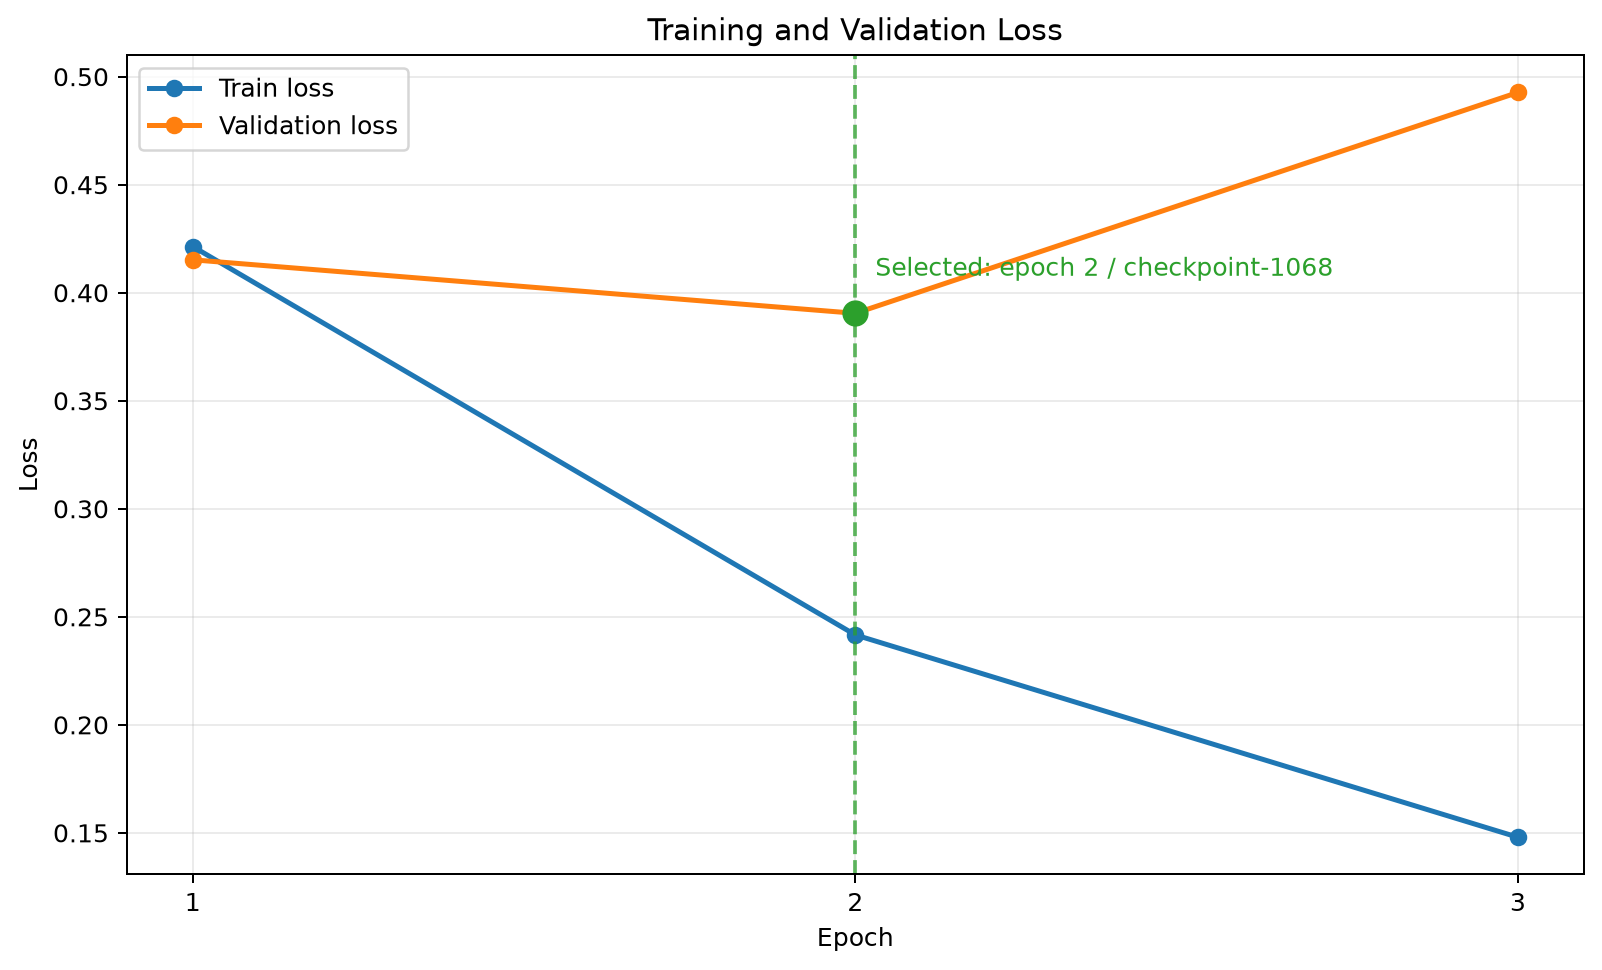

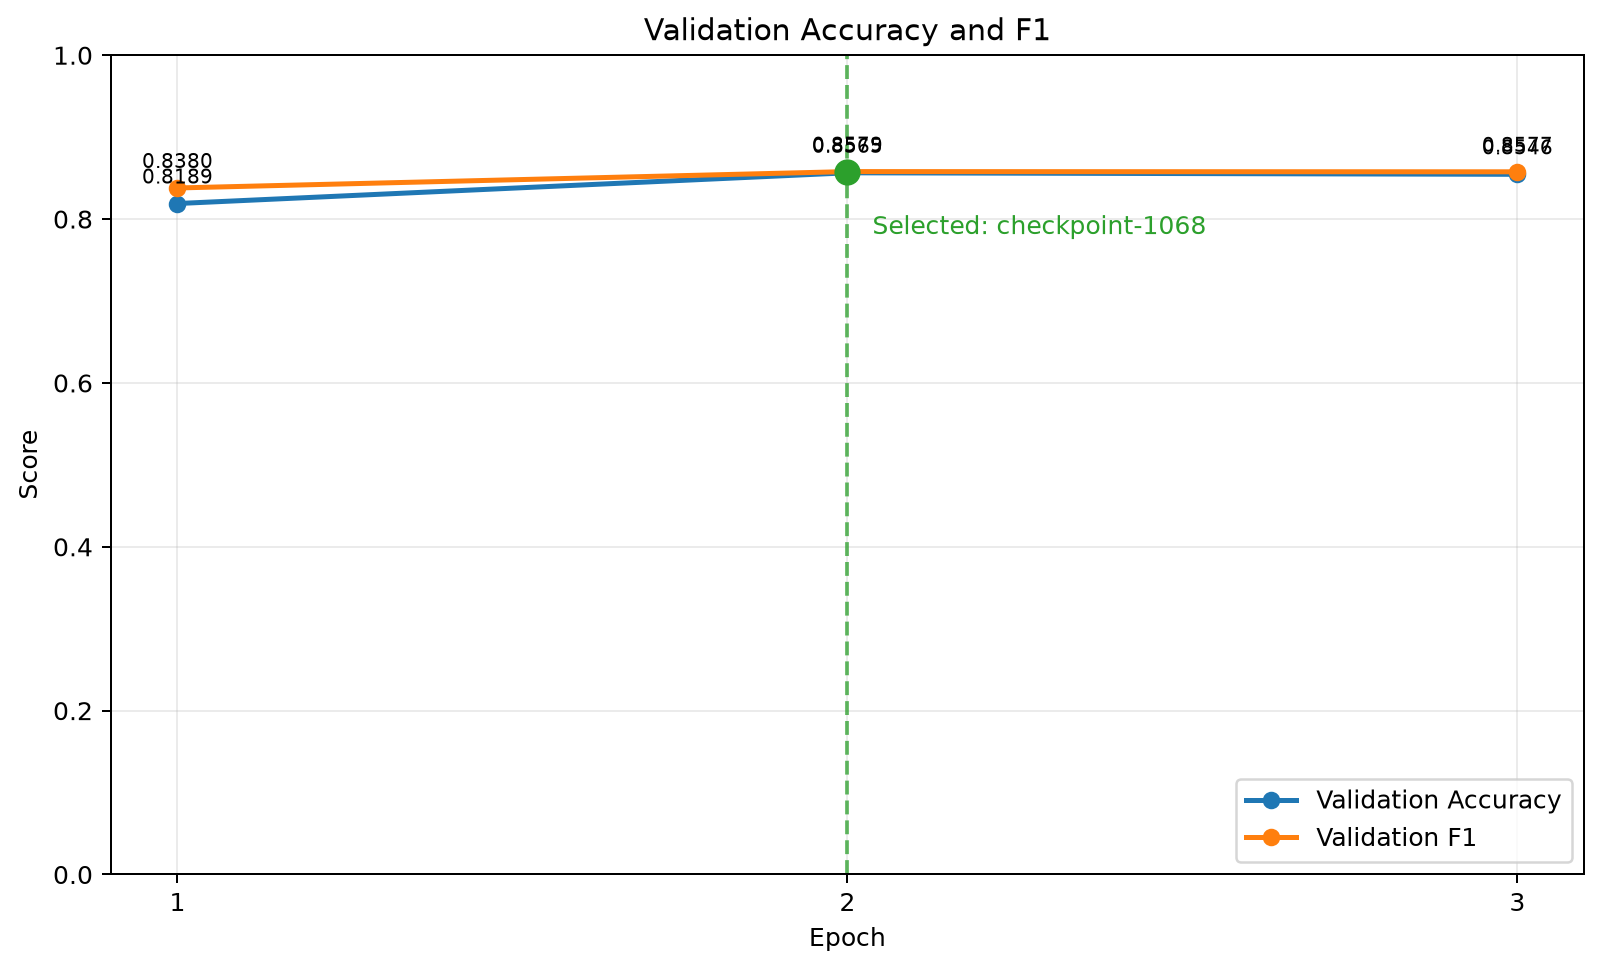

,epoch,step,checkpoint,eval_loss,eval_f1
0,2.0,1068,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,0.390465,0.857939


,train_loss,validation_loss,validation_accuracy,validation_f1
epoch_1_to_2,-0.179758,-0.024765,0.037523,0.019987
epoch_2_to_3,-0.093646,0.102227,-0.001876,-0.000271


### Generalization interpretation

Epoch 1 to 2 improves both fit and Validation behavior. From epoch 2 to 3, Train loss continues to decrease while Validation loss increases and Validation Accuracy/F1 do not improve. This indicates generalization begins to worsen after epoch 2 and is consistent with the onset of overfitting. With only three epochs and one run, this is limited evidence rather than a definitive broad conclusion.

,status,training_performed,model_loaded,model_evaluated,dataset_loaded,test_accessed,checkpoint_changed,phase_11_started
0,PASS,False,False,False,False,False,False,False


Phase 10 learning-curves and training-analysis verification: PASS


In [23]:
# Phase 10: artifact-only learning curves and analysis
from processing_own_phase.phase_10_learning_curves import analyze_learning_curves

phase_10_analysis = analyze_learning_curves()
assert phase_10_analysis['status'] == 'PASS', phase_10_analysis
assert phase_10_analysis['test_accessed'] is False

display(pd.DataFrame(phase_10_analysis['epoch_records']))
display(Image(filename=phase_10_analysis['figures']['loss_curves']['path']))
display(Image(filename=phase_10_analysis['figures']['validation_metrics']['path']))
display(pd.DataFrame([phase_10_analysis['selected_checkpoint']]))
display(pd.DataFrame(phase_10_analysis['epoch_deltas']).T)
display(Markdown('### Generalization interpretation'))
display(Markdown(phase_10_analysis['generalization_interpretation']))
display(pd.DataFrame([{
    key: phase_10_analysis[key] for key in (
        'status', 'training_performed', 'model_loaded', 'model_evaluated',
        'dataset_loaded', 'test_accessed', 'checkpoint_changed',
        'phase_11_started',
    )
}]))
print('Phase 10 learning-curves and training-analysis verification: PASS')

## Phase 11 — Validation Verification and Final Test Evaluation

Reload the fixed Phase 9 epoch-2 checkpoint, reproduce its Validation metrics within the approved tolerances, and only then perform the single final Test evaluation. Later Run All executions load the frozen Phase 11 artifacts and do not evaluate Test again.

In [24]:
# Phase 11: guarded Validation verification + one-time final Test evaluation
from processing_own_phase.phase_11_final_evaluation import (
    run_or_load_phase_11, load_phase_11_report,
)

phase_11_run = run_or_load_phase_11(
    validation_dataset=tokenized_dataset['validation'],
    data_collator=get_data_collator(tokenizer),
    tokenizer=tokenizer,
    test_data_provider=lambda: (tokenized_dataset['test'], dataset['test']),
)
phase_11_report = load_phase_11_report()
assert phase_11_report['checkpoint']['status'] == 'PASS'
assert phase_11_report['validation']['status'] == 'PASS'
assert phase_11_report['test']['status'] == 'PASS'
assert phase_11_report['manifest']['status'] == 'FINAL_TEST_COMPLETE'
assert phase_11_report['manifest']['test_evaluation_count'] == 1
assert phase_11_report['manifest']['test_used_for_selection'] is False
assert phase_11_report['manifest']['phase_12_started'] is False

checkpoint_fields = (
    'checkpoint', 'epoch', 'step', 'weight_sha256', 'model_class',
    'model_type', 'num_labels', 'id2label', 'label2id', 'paths_agree',
)
display(pd.DataFrame([{key: phase_11_report['checkpoint'][key] for key in checkpoint_fields}]))
validation_rows = [
    {'metric': metric, **comparison}
    for metric, comparison in phase_11_report['validation']['comparisons'].items()
]
display(Markdown('### Reloaded Validation reproducibility gate'))
display(pd.DataFrame(validation_rows))
display(Markdown('### Final Test metrics — evaluated once after Validation PASS'))
display(pd.DataFrame([phase_11_report['test']['metrics']]))
comparison_rows = [
    {'metric': metric,
     'Validation': phase_11_report['validation']['metrics'][metric],
     'Final Test': phase_11_report['test']['metrics'][metric]}
    for metric in ('loss', 'accuracy', 'precision', 'recall', 'f1')
]
display(Markdown('### Validation vs Final Test'))
display(pd.DataFrame(comparison_rows))
display(pd.DataFrame([{
    'status': phase_11_report['manifest']['status'],
    'guard_action': phase_11_run['guard_action'],
    'test_evaluation_count': phase_11_report['manifest']['test_evaluation_count'],
    'prediction_count': phase_11_report['prediction_count'],
    'prediction_artifact': phase_11_report['prediction_path'],
    'test_used_for_selection': phase_11_report['manifest']['test_used_for_selection'],
    'training_performed': phase_11_report['manifest']['training_performed'],
    'checkpoint_changed_after_test': phase_11_report['manifest']['checkpoint_changed_after_test'],
    'phase_12_started': phase_11_report['manifest']['phase_12_started'],
}]))
display(Markdown(
    '**Test policy:** the official Test split was used only for the single final evaluation, '
    'never for model/checkpoint selection. Future Run All executions load verified artifacts.'
))
print('Phase 11 Validation and one-time Final Test evaluation: PASS')

,checkpoint,epoch,step,weight_sha256,model_class,model_type,num_labels,id2label,label2id,paths_agree
0,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,2.0,1068,22fcd24d3db7bfebc8ea1dd4f6c0665be5176e34de005e...,DistilBertForSequenceClassification,distilbert,2,"{'0': 'NEGATIVE', '1': 'POSITIVE'}","{'NEGATIVE': 0, 'POSITIVE': 1}",True


### Reloaded Validation reproducibility gate

,metric,phase_09_expected,reloaded_value,absolute_delta,absolute_tolerance,relative_tolerance,pass
0,loss,0.390465,0.390465,0.0,0.000010,0.0,True
1,accuracy,0.856473,0.856473,0.0,0.000001,0.0,True
2,precision,0.849265,0.849265,0.0,0.000001,0.0,True
3,recall,0.866792,0.866792,0.0,0.000001,0.0,True
4,f1,0.857939,0.857939,0.0,0.000001,0.0,True


### Final Test metrics — evaluated once after Validation PASS

,loss,accuracy,precision,recall,f1
0,0.448512,0.845216,0.845865,0.844278,0.84507


### Validation vs Final Test

,metric,Validation,Final Test
0,loss,0.390465,0.448512
1,accuracy,0.856473,0.845216
2,precision,0.849265,0.845865
3,recall,0.866792,0.844278
4,f1,0.857939,0.845070


,status,guard_action,test_evaluation_count,prediction_count,prediction_artifact,test_used_for_selection,training_performed,checkpoint_changed_after_test,phase_12_started
0,FINAL_TEST_COMPLETE,loaded_verified_phase_11_artifacts_no_test_ree...,1,1066,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,False,False,False,False


**Test policy:** the official Test split was used only for the single final evaluation, never for model/checkpoint selection. Future Run All executions load verified artifacts.

Phase 11 Validation and one-time Final Test evaluation: PASS


## Phase 12 — Confusion Matrix and Error Analysis

Analyze only the frozen Phase 11 prediction artifact. This section derives the confusion matrix, class-level behavior and deterministic representative errors without loading a model/dataset, reevaluating Test, changing the checkpoint or starting Phase 13.

### Frozen Final-Test confusion matrix

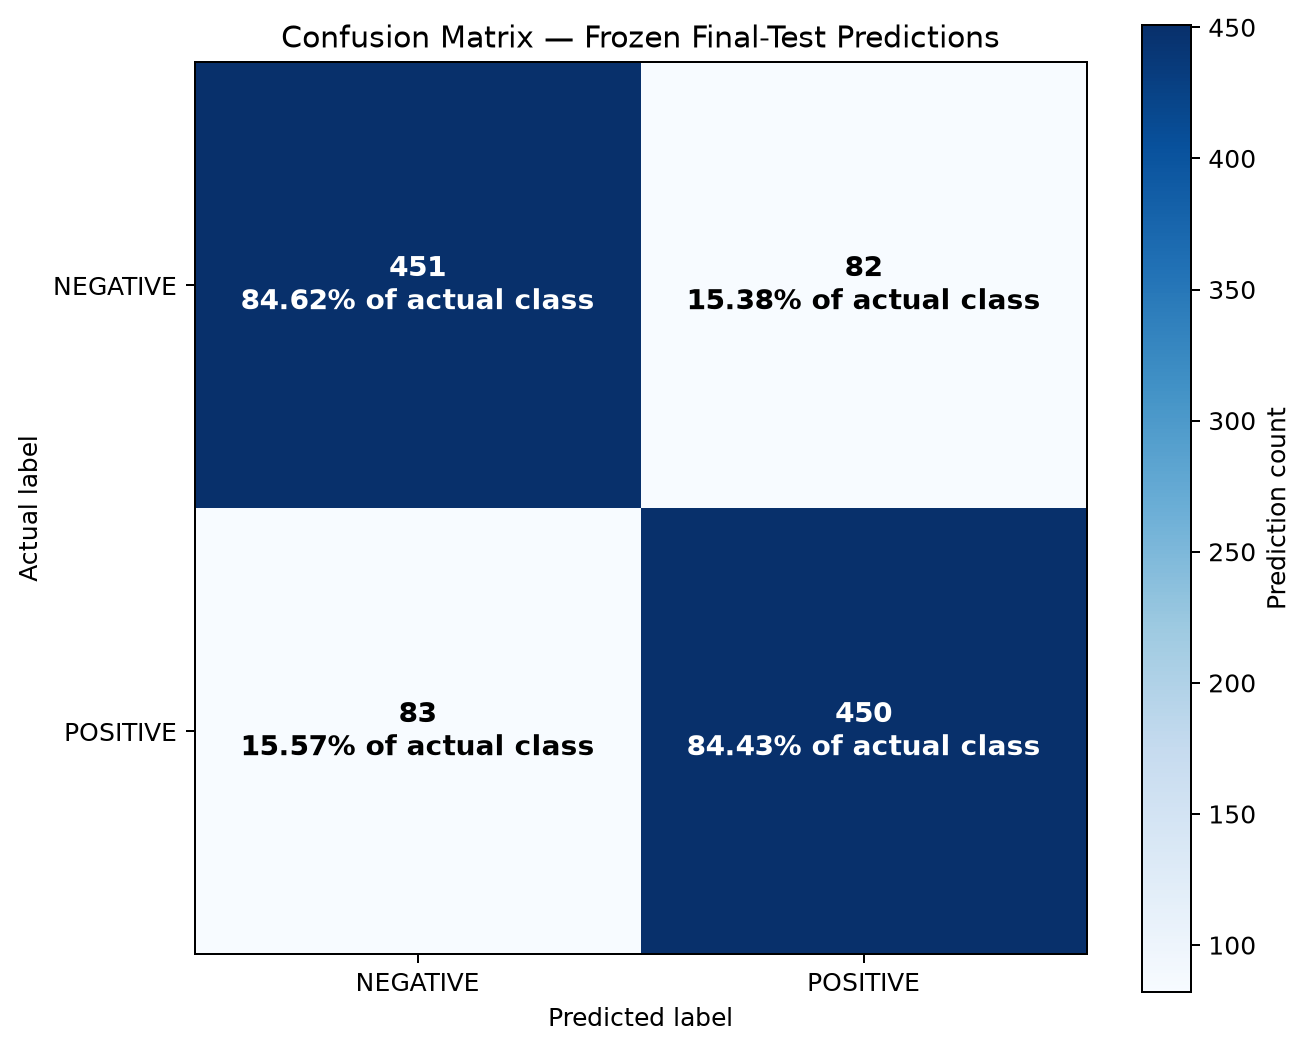

,cell,actual,predicted,count,overall_rate,row_rate
0,TN,NEGATIVE,NEGATIVE,451,0.423077,0.846154
1,FP,NEGATIVE,POSITIVE,82,0.076923,0.153846
2,FN,POSITIVE,NEGATIVE,83,0.077861,0.155722
3,TP,POSITIVE,POSITIVE,450,0.422139,0.844278


### Confusion-derived metrics verified against Phase 11

,metric,phase_11_value,derived_value,absolute_delta,tolerance,pass
0,accuracy,0.845216,0.845216,0.0,1.000000e-12,True
1,precision,0.845865,0.845865,0.0,1.000000e-12,True
2,recall,0.844278,0.844278,0.0,1.000000e-12,True
3,f1,0.845070,0.845070,0.0,1.000000e-12,True


### Class-level conditional accuracy and error rate

,actual_class,total,correct,errors,conditional_accuracy,error_rate,error_direction
0,NEGATIVE,533,451,82,0.846154,0.153846,NEGATIVE_TO_POSITIVE
1,POSITIVE,533,450,83,0.844278,0.155722,POSITIVE_TO_NEGATIVE


...

### Descriptive error evidence

,count,confidence,character_length,word_length
correct,901,"{'mean': 0.9433190382678025, 'median': 0.98275...","{'mean': 114.70366259711432, 'median': 111.0, ...","{'mean': 21.063263041065483, 'median': 20.0, '..."
incorrect,165,"{'mean': 0.8581111048207138, 'median': 0.92974...","{'mean': 120.0, 'median': 119.0, 'minimum': 28...","{'mean': 22.078787878787878, 'median': 21.0, '..."
negative_to_positive,82,"{'mean': 0.85551163481503, 'median': 0.9299167...","{'mean': 119.79268292682927, 'median': 117.5, ...","{'mean': 21.5609756097561, 'median': 21.0, 'mi..."
positive_to_negative,83,"{'mean': 0.8606792559106666, 'median': 0.92864...","{'mean': 120.20481927710843, 'median': 121.0, ...","{'mean': 22.59036144578313, 'median': 21.0, 'm..."
actual_negative,533,"{'mean': 0.9231163881733091, 'median': 0.97411...","{'mean': 115.18949343339587, 'median': 111.0, ...","{'mean': 21.339587242026266, 'median': 20.0, '..."
actual_positive,533,"{'mean': 0.937143997895561, 'median': 0.984652...","{'mean': 115.85741088180113, 'median': 114.0, ...","{'mean': 21.101313320825515, 'median': 20.0, '..."


The frozen artifact contains 165 errors: 82 NEGATIVE→POSITIVE and 83 POSITIVE→NEGATIVE. The highest-confidence error is 0.9915. Length, confidence and lexical flags below are descriptive co-occurrences only; they do not establish that a text feature caused an error.

,status,total_predictions,correct,incorrect,representative_errors,test_evaluation_count,frozen_sources_unchanged,test_evaluated,checkpoint_changed,phase_13_started
0,PASS,1066,901,165,10,1,True,False,False,False


Phase 12 confusion-matrix and frozen-artifact error analysis: PASS


In [25]:
# Phase 12: frozen-artifact confusion matrix + deterministic error analysis
from processing_own_phase.phase_12_error_analysis import analyze_phase_12

phase_12_result = analyze_phase_12()
phase_12_confusion = phase_12_result['confusion']
phase_12_errors = phase_12_result['error_samples']
phase_12_analysis = phase_12_result['analysis']
assert phase_12_result['status'] == 'PASS'
assert phase_12_analysis['test_evaluation_count'] == 1
assert phase_12_analysis['model_loaded'] is False
assert phase_12_analysis['dataset_loaded'] is False
assert phase_12_analysis['test_provider_called'] is False
assert phase_12_analysis['test_evaluated'] is False
assert phase_12_analysis['training_performed'] is False
assert phase_12_analysis['checkpoint_changed'] is False
assert phase_12_analysis['phase_13_started'] is False

display(Markdown('### Frozen Final-Test confusion matrix'))
display(Image(filename=phase_12_confusion['figure']['path']))
display(pd.DataFrame(phase_12_confusion['cells']))
display(Markdown('### Confusion-derived metrics verified against Phase 11'))
display(pd.DataFrame(phase_12_confusion['phase_11_metric_comparisons']))
display(Markdown('### Class-level conditional accuracy and error rate'))
display(pd.DataFrame(phase_12_confusion['class_level']))

display(Markdown('### Error directions and deterministic selection'))
display(pd.DataFrame([phase_12_errors['direction_counts']]))
representative_rows = []
for row in phase_12_errors['representative_errors']:
    representative_rows.append({
        'global_rank': row['global_error_rank'],
        'direction_rank': row['direction_rank'],
        'sample_id': row['sample_id'],
        'error_direction': row['error_direction'],
        'true_label': row['true_label_name'],
        'predicted_label': row['predicted_label_name'],
        'confidence': row['confidence'],
        'character_length': row['character_length'],
        'word_length': row['word_length'],
        **row['lexical_flags'],
        'text': row['text'],
    })
display(pd.DataFrame(representative_rows))

display(Markdown('### Descriptive error evidence'))
display(pd.DataFrame(phase_12_analysis['group_summaries']).T)
display(Markdown(phase_12_analysis['interpretation']))
display(pd.DataFrame([{
    'status': phase_12_analysis['status'],
    'total_predictions': phase_12_confusion['total'],
    'correct': phase_12_confusion['correct'],
    'incorrect': phase_12_confusion['incorrect'],
    'representative_errors': phase_12_analysis['representative_count'],
    'test_evaluation_count': phase_12_analysis['test_evaluation_count'],
    'frozen_sources_unchanged': phase_12_analysis['frozen_sources_unchanged'],
    'test_evaluated': phase_12_analysis['test_evaluated'],
    'checkpoint_changed': phase_12_analysis['checkpoint_changed'],
    'phase_13_started': phase_12_analysis['phase_13_started'],
}]))
print('Phase 12 confusion-matrix and frozen-artifact error analysis: PASS')

## Phase 13 — New-Sentence Inference

Run guarded inference only on newly authored custom sentences using the fixed epoch-2 `checkpoint-1068`. The module verifies the Phase 11 SHA-256 fingerprint, reuses the locked Phase 6 tokenizer contract (`max_length=80`, truncation and dynamic padding), and never loads or reevaluates Test.

In [26]:
# Phase 13: guarded custom-text inference using the authoritative checkpoint
from processing_own_phase.phase_13_new_sentence_inference import (
    DEFAULT_CUSTOM_SENTENCES, run_or_load_phase_13,
)

phase_13_report = run_or_load_phase_13(DEFAULT_CUSTOM_SENTENCES)
assert phase_13_report['status'] == 'PASS'
assert phase_13_report['checkpoint']['checkpoint_name'] == 'checkpoint-1068'
assert phase_13_report['checkpoint']['epoch'] == 2.0
assert phase_13_report['checkpoint']['step'] == 1068
assert phase_13_report['logits_shape'] == [len(DEFAULT_CUSTOM_SENTENCES), 2]
assert all(phase_13_report['verification']['checks'].values())
assert phase_13_report['training_performed'] is False
assert phase_13_report['test_accessed'] is False
assert phase_13_report['test_evaluated'] is False
assert phase_13_report['test_evaluation_count'] == 1
assert phase_13_report['checkpoint_changed'] is False
assert phase_13_report['phase_14_started'] is False

display(Markdown('### Authoritative checkpoint and preprocessing contract'))
display(pd.DataFrame([{
    'checkpoint': phase_13_report['checkpoint']['checkpoint_name'],
    'epoch': phase_13_report['checkpoint']['epoch'],
    'step': phase_13_report['checkpoint']['step'],
    'SHA-256': phase_13_report['checkpoint']['weight_sha256'],
    'tokenizer': phase_13_report['preprocessing']['tokenizer_checkpoint'],
    'max_length': phase_13_report['preprocessing']['max_length'],
    'padding': phase_13_report['preprocessing']['batch_padding'],
    'device': phase_13_report['device'],
}]))

display(Markdown('### Custom-sentence sentiment predictions'))
display(pd.DataFrame([{
    'text': row['text'],
    'prediction': row['predicted_label_name'],
    'NEGATIVE probability': row['negative_probability'],
    'POSITIVE probability': row['positive_probability'],
    'confidence': row['confidence'],
} for row in phase_13_report['results']]))

display(Markdown('### Verification and isolation evidence'))
display(pd.DataFrame([phase_13_report['verification']['checks']]))
display(pd.DataFrame([{
    'status': phase_13_report['status'],
    'guard_action': phase_13_report['guard_action'],
    'input_provenance': phase_13_report['input_provenance'],
    'training_performed': phase_13_report['training_performed'],
    'test_accessed': phase_13_report['test_accessed'],
    'test_evaluated': phase_13_report['test_evaluated'],
    'test_evaluation_count': phase_13_report['test_evaluation_count'],
    'checkpoint_changed': phase_13_report['checkpoint_changed'],
    'artifact': phase_13_report['artifact_path'],
}]))
display(Markdown(
    '**Isolation policy:** all examples are custom-authored; the official Test split was '    'not accessed or reevaluated, no training occurred, and checkpoint-1068 remained unchanged.'
))
print('Phase 13 new-sentence inference verification: PASS')

### Authoritative checkpoint and preprocessing contract

,checkpoint,epoch,step,SHA-256,tokenizer,max_length,padding,device
0,checkpoint-1068,2.0,1068,22fcd24d3db7bfebc8ea1dd4f6c0665be5176e34de005e...,distilbert/distilbert-base-uncased,80,DataCollatorWithPadding_dynamic,cpu


### Custom-sentence sentiment predictions

,text,prediction,NEGATIVE probability,POSITIVE probability,confidence
0,"The performances were warm, convincing, and de...",POSITIVE,0.006299,0.993701,0.993701
1,"The story was tedious, predictable, and painfu...",NEGATIVE,0.987616,0.012384,0.987616
2,It is not a bad movie at all.,POSITIVE,0.074808,0.925192,0.925192
3,"The acting is excellent, but the plot is disap...",NEGATIVE,0.977097,0.022903,0.977097


### Verification and isolation evidence

,logits_shape_B_2,logits_finite,probabilities_finite,probabilities_in_0_1,probability_rows_sum_to_one,predicted_labels_deterministic,probabilities_deterministic,model_remains_in_eval_mode,output_count_equals_input_count,input_order_preserved,all_record_checks_pass,checkpoint_fingerprint_unchanged,single_input_contract_verified,batch_input_contract_verified
0,True,True,True,True,True,True,True,True,True,True,True,True,True,True


,status,guard_action,input_provenance,training_performed,test_accessed,test_evaluated,test_evaluation_count,checkpoint_changed,artifact
0,PASS,loaded_verified_phase_13_artifact_no_model_inf...,custom_authored_not_test,False,False,False,1,False,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...


**Isolation policy:** all examples are custom-authored; the official Test split was not accessed or reevaluated, no training occurred, and checkpoint-1068 remained unchanged.

Phase 13 new-sentence inference verification: PASS


## Phase 14 — Save & Reload

Verify the authoritative epoch-2 `checkpoint-1068`, save a reusable Hugging Face model/tokenizer package once, and prove that its locally reloaded state and predictions are equivalent. Later Run All executions verify/load the package without resaving, training or Test reevaluation.

In [27]:
# Phase 14: guarded package integrity + save/reload equivalence
from processing_own_phase.phase_14_save_reload import run_or_load_phase_14

phase_14_report = run_or_load_phase_14()
assert phase_14_report['status'] == 'PASS'
assert phase_14_report['source_checkpoint']['checkpoint_name'] == 'checkpoint-1068'
assert phase_14_report['source_checkpoint']['epoch'] == 2.0
assert phase_14_report['source_checkpoint']['step'] == 1068
assert phase_14_report['state_dict_equivalence']['status'] == 'PASS'
assert phase_14_report['state_dict_equivalence']['all_tensors_exact_equal'] is True
assert phase_14_report['prediction_equivalence']['status'] == 'PASS'
assert all(phase_14_report['completion_checks'].values())
assert phase_14_report['training_performed'] is False
assert phase_14_report['test_accessed'] is False
assert phase_14_report['test_evaluated'] is False
assert phase_14_report['test_evaluation_count'] == 1
assert phase_14_report['checkpoint_selected_or_changed'] is False
assert phase_14_report['phase_15_started'] is False

display(Markdown('### Saved reusable package'))
display(pd.DataFrame([{
    'package_path': phase_14_report['package_path'],
    'source_checkpoint': phase_14_report['source_checkpoint']['checkpoint_name'],
    'epoch': phase_14_report['source_checkpoint']['epoch'],
    'step': phase_14_report['source_checkpoint']['step'],
    'source_SHA256': phase_14_report['source_checkpoint']['weight_sha256'],
    'model_type': phase_14_report['reloaded_model']['model_type'],
    'num_labels': phase_14_report['reloaded_model']['num_labels'],
    'max_length': phase_14_report['preprocessing']['max_length'],
}]))
display(Markdown('### Package files and fingerprints'))
display(pd.DataFrame(phase_14_report['package_files'].values()))

display(Markdown('### Original vs locally reloaded predictions'))
display(pd.DataFrame(phase_14_report['prediction_equivalence']['predictions']))
display(Markdown('### Equivalence checks'))
display(pd.DataFrame([{
    'state_dict_exact': phase_14_report['state_dict_equivalence']['all_tensors_exact_equal'],
    'tensor_count': phase_14_report['state_dict_equivalence']['tensor_count'],
    'logits_max_abs_diff': phase_14_report['prediction_equivalence']['logits_max_abs_diff'],
    'probability_max_abs_diff': phase_14_report['prediction_equivalence']['probability_max_abs_diff'],
    'confidence_max_abs_diff': phase_14_report['prediction_equivalence']['confidence_max_abs_diff'],
    **phase_14_report['prediction_equivalence']['tokenizer_checks'],
}]))
display(pd.DataFrame([{
    'status': phase_14_report['status'],
    'guard_action': phase_14_report['guard_action'],
    'training_performed': phase_14_report['training_performed'],
    'test_accessed': phase_14_report['test_accessed'],
    'test_evaluated': phase_14_report['test_evaluated'],
    'test_evaluation_count': phase_14_report['test_evaluation_count'],
    'checkpoint_changed': phase_14_report['checkpoint_selected_or_changed'],
    'manifest': phase_14_report['package_manifest_path'],
    'verification_artifact': phase_14_report['verification_artifact_path'],
}]))
display(Markdown(
    '**Isolation policy:** the package was verified locally without retraining, checkpoint '    'selection/change or Test reevaluation; the final Test evaluation count remains one.'
))
print('Phase 14 save/reload package verification: PASS')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

### Saved reusable package

,package_path,source_checkpoint,epoch,step,source_SHA256,model_type,num_labels,max_length
0,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,checkpoint-1068,2.0,1068,22fcd24d3db7bfebc8ea1dd4f6c0665be5176e34de005e...,distilbert,2,80


### Package files and fingerprints

,relative_path,bytes,sha256
0,config.json,762,2c9cd5b950a56f19713c5f24c82ab5c77d72b239994046...
1,model.safetensors,267832560,22fcd24d3db7bfebc8ea1dd4f6c0665be5176e34de005e...
2,tokenizer.json,711396,d241a60d5e8f04cc1b2b3e9ef7a4921b27bf526d9f6050...
3,tokenizer_config.json,349,04c4c3f8c445a1415ccbb7578053de0d66aeeb2f34b2be...


...

### Equivalence checks

,state_dict_exact,tensor_count,logits_max_abs_diff,probability_max_abs_diff,confidence_max_abs_diff,input_ids_exact_equal,attention_mask_exact_equal,batch_shapes_equal,special_tokens_equal,special_token_ids_equal,source_dynamic_padding_pass,reloaded_dynamic_padding_pass
0,True,104,0.0,0.0,0.0,True,True,True,True,True,True,True


,status,guard_action,training_performed,test_accessed,test_evaluated,test_evaluation_count,checkpoint_changed,manifest,verification_artifact
0,PASS,loaded_verified_phase_14_package_no_resave,False,False,False,1,False,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...


**Isolation policy:** the package was verified locally without retraining, checkpoint selection/change or Test reevaluation; the final Test evaluation count remains one.

Phase 14 save/reload package verification: PASS


## Phase 15 — Final Summary

Consolidate the verified Phase 0–14 artifacts into the final Practice 3 conclusion. This section is artifact-only: it does not load a model/dataset, train, infer, evaluate Test, change a checkpoint or resave the Phase 14 package.

### End-to-end verified pipeline

,phase,name,processing,verified_output,status
0,0–1,Overview & Environment,Define the two-exercise workflow and reproduci...,Environment/package contract,PASS
1,2,Pretrained Inference,Run the already fine-tuned SST-2 sentiment model,Sentiment labels and confidence examples,PASS
2,3,Tokenization Investigation,"Inspect tokens, IDs, masks and decode behavior",Verified tokenizer understanding,PASS
3,4,Dataset Loading,Load and verify Rotten Tomatoes fixed splits,Train/Validation/Test contract,PASS
4,5,EDA & Sanity Checks,"Inspect text quality, labels, duplicates, over...",Evidence for maximum token length,PASS
5,6,Preprocessing,Tokenize all splits with truncation and dynami...,Verified model-ready inputs,PASS
6,7,Model Construction,Attach a two-label classification head to gene...,Forward-pass-verified baseline model,PASS
7,8,Metrics & Configuration,"Define metrics, training arguments and checkpo...",Locked baseline configuration,PASS
8,9,Fine-Tuning,Train for three epochs using Train and Validat...,History and three checkpoints,PASS
9,10,Learning Curves,Analyze artifact-only training/Validation traj...,Selected epoch and cautious generalization evi...,PASS


### Dataset and preprocessing contract

,dataset,train,validation,test,labels,tokenizer,max_length,dynamic_padding
0,cornell-movie-review-data/rotten_tomatoes,8530,1066,1066,"{'train': [0, 1], 'validation': [0, 1], 'test'...",distilbert/distilbert-base-uncased,80,DataCollatorWithPadding


### Selected final model

,architecture,model_class,num_labels,label_mapping,selected_checkpoint,selected_checkpoint_path,epoch,step,selection_reason,tie_breaker,remaining_tie,selected_validation_loss,selected_validation_f1,test_used_for_selection,authoritative_weight_sha256
0,DistilBERT for sequence classification,DistilBertForSequenceClassification,2,"{'0': 'NEGATIVE', '1': 'POSITIVE'}",checkpoint-1068,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,2.0,1068,minimum eval_loss,maximum eval_f1,earlier epoch/checkpoint,0.390465,0.857939,False,22fcd24d3db7bfebc8ea1dd4f6c0665be5176e34de005e...


### Training trajectory and generalization

,epoch,step,train_loss,validation_loss,validation_accuracy,validation_f1
0,1.0,534,0.421368,0.415231,0.818949,0.837951
1,2.0,1068,0.241609,0.390465,0.856473,0.857939
2,3.0,1602,0.147964,0.492693,0.854597,0.857668


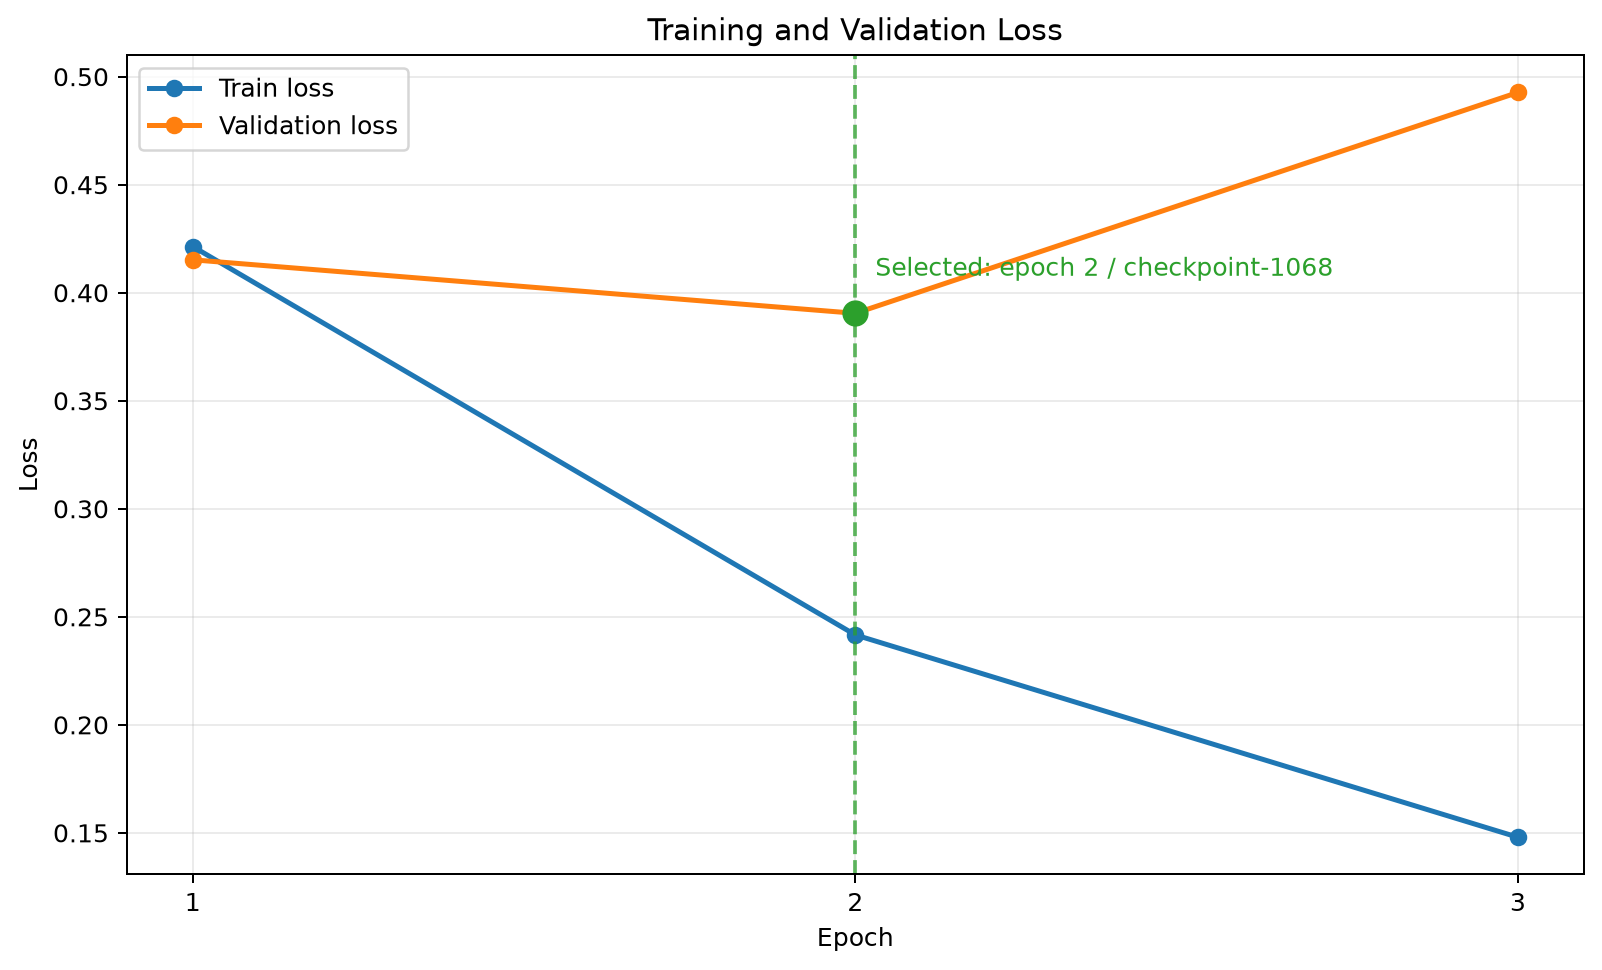

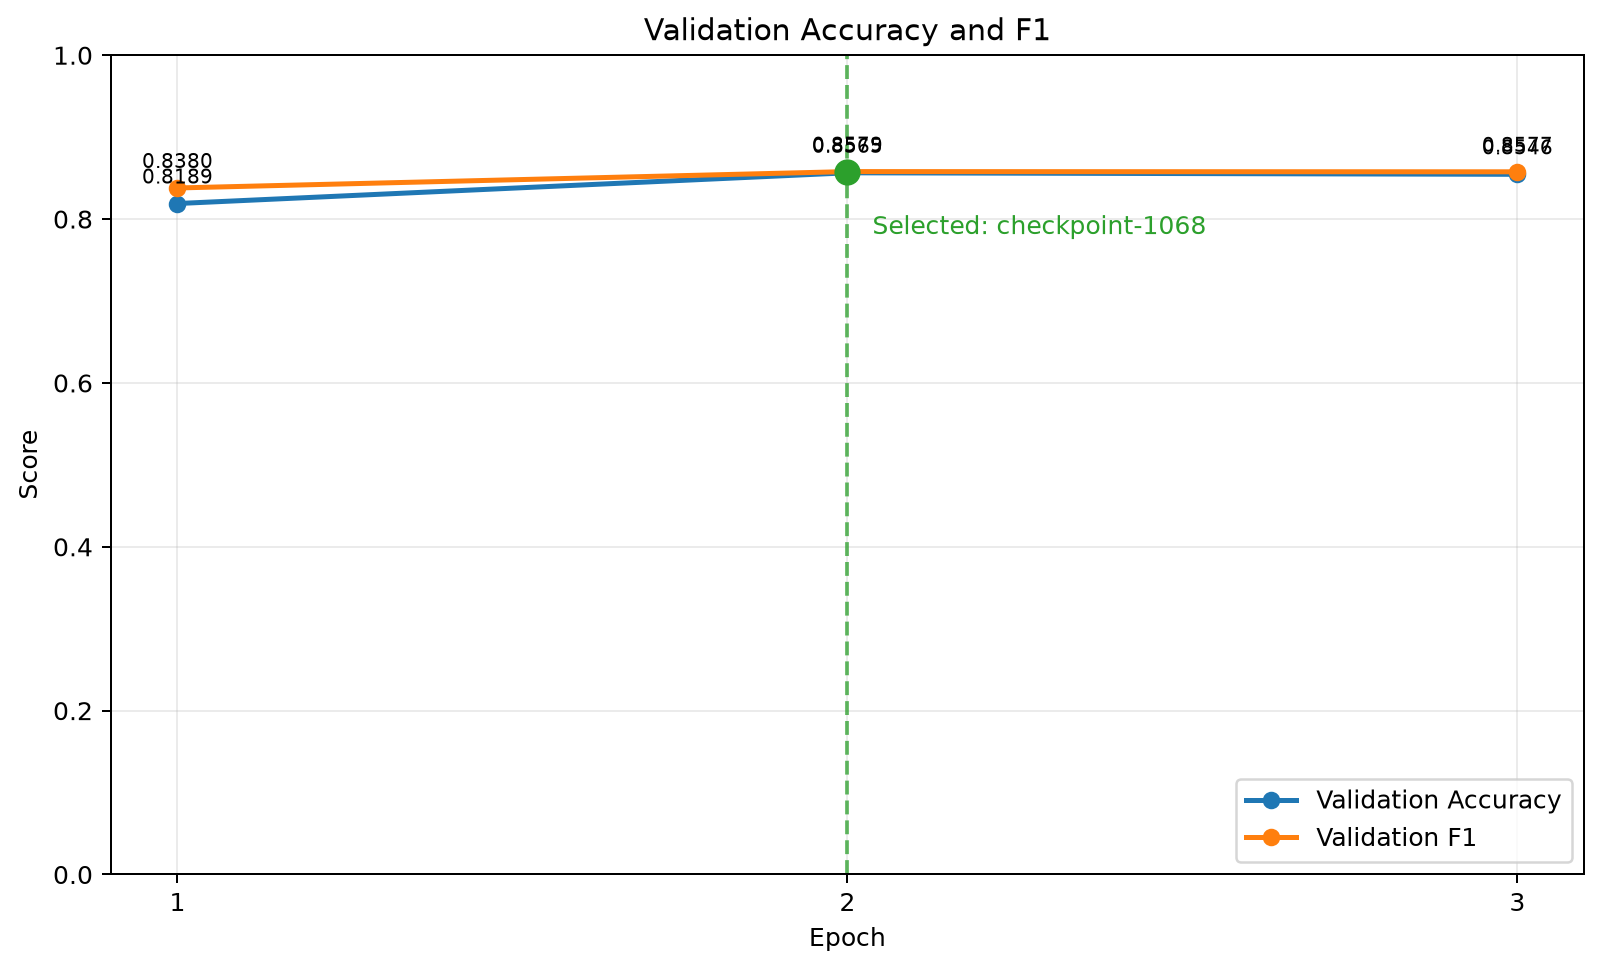

Epoch 1 to 2 improves both fit and Validation behavior. From epoch 2 to 3, Train loss continues to decrease while Validation loss increases and Validation Accuracy/F1 do not improve. This indicates generalization begins to worsen after epoch 2 and is consistent with the onset of overfitting. With only three epochs and one run, this is limited evidence rather than a definitive broad conclusion.

**Evidence limit:** Three epochs and one seeded baseline run are limited evidence; no broad conclusion is claimed.

### Validation and one-time Final Test metrics

,metric,Validation,Final Test
0,loss,0.390465,0.448512
1,accuracy,0.856473,0.845216
2,precision,0.849265,0.845865
3,recall,0.866792,0.844278
4,f1,0.857939,0.845070


### Confusion matrix and frozen error analysis

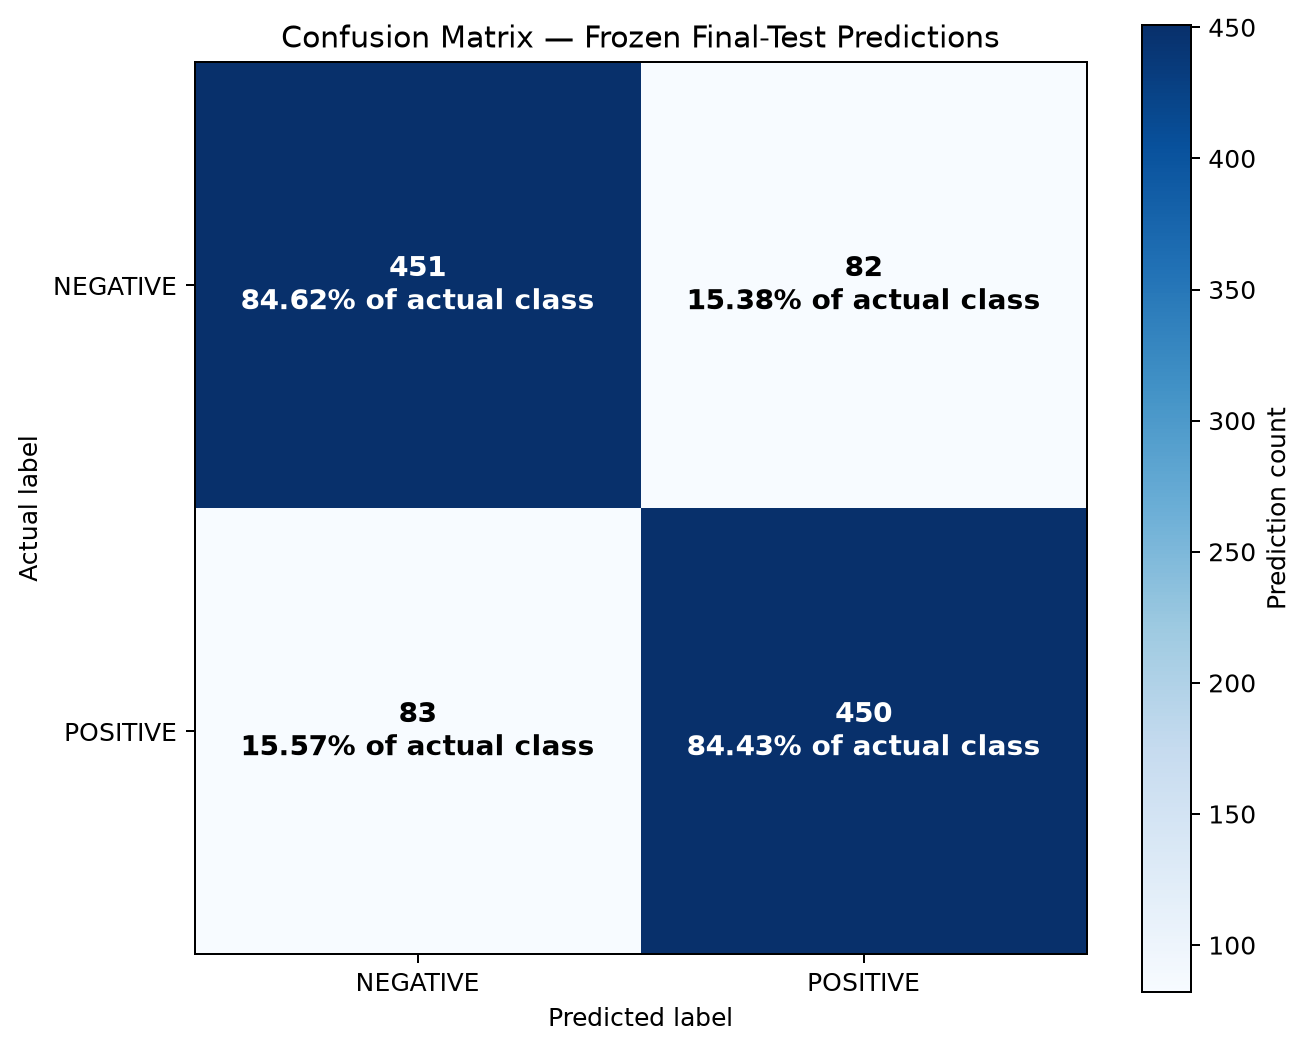

,TN,FP,FN,TP,total,correct,incorrect,NEGATIVE_TO_POSITIVE,POSITIVE_TO_NEGATIVE
0,451,82,83,450,1066,901,165,82,83


The frozen artifact contains 165 errors: 82 NEGATIVE→POSITIVE and 83 POSITIVE→NEGATIVE. The highest-confidence error is 0.9915. Length, confidence and lexical flags below are descriptive co-occurrences only; they do not establish that a text feature caused an error.

### Custom inference and saved-package evidence

,input_index,text,predicted_label,confidence
0,0,"The performances were warm, convincing, and de...",POSITIVE,0.993701
1,1,"The story was tedious, predictable, and painfu...",NEGATIVE,0.987616
2,2,It is not a bad movie at all.,POSITIVE,0.925192
3,3,"The acting is excellent, but the plot is disap...",NEGATIVE,0.977097


,package_path,state_dict_exact_equal,state_tensor_count,logits_max_abs_diff,probability_max_abs_diff,confidence_max_abs_diff
0,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,True,104,0.0,0.0,0.0


...

- The baseline was trained for only three epochs.
- Fine-tuning evidence comes from one DistilBERT baseline configuration and one full seeded run.
- No broad hyperparameter search or multi-seed robustness study was performed.
- The implemented task is English binary sentiment classification only.
- Evaluation evidence is tied to the Rotten Tomatoes dataset and its fixed splits.
- Mixed sentiment, negation and high-confidence errors remain observable challenges; descriptive flags do not establish causes.
- The project reports aggregate evaluation and artifact-based error analysis, not production monitoring.
- A local package was verified, but no production API, serving infrastructure, load/latency test, drift monitoring, security review or deployment was implemented.

### Final conclusion

Phase 0–14 evidence is internally consistent and PASS; Practice 3 implementation is complete without new model execution in Phase 15.

,status,guard_action,artifact_only,model_loaded,training_performed,test_evaluated,test_evaluation_count,package_resaved,summary_json,summary_markdown
0,PASS,built_artifact_only_phase_15_summary,True,False,False,False,1,False,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...,/Users/vientu/Deep Learning/TOTAL_LABPARACTICE...


PHASE 15: PASS — PRACTICE 3 COMPLETE


In [28]:
# Phase 15: artifact-only final project summary
from processing_own_phase.phase_15_final_summary import run_or_load_phase_15

phase_15_report = run_or_load_phase_15()
assert phase_15_report['status'] == 'PASS'
assert all(status == 'PASS' for status in phase_15_report['phase_status'].values())
assert all(phase_15_report['verification_checks'].values())
assert phase_15_report['final_model']['selected_checkpoint'] == 'checkpoint-1068'
assert phase_15_report['final_model']['epoch'] == 2.0
assert phase_15_report['final_model']['step'] == 1068
assert phase_15_report['dataset_contract']['split_counts'] == {'train': 8530, 'validation': 1066, 'test': 1066}
assert phase_15_report['test_evaluation_count'] == 1
assert phase_15_report['model_loaded'] is False
assert phase_15_report['dataset_loaded'] is False
assert phase_15_report['training_performed'] is False
assert phase_15_report['inference_performed'] is False
assert phase_15_report['test_accessed'] is False
assert phase_15_report['test_evaluated'] is False
assert phase_15_report['checkpoint_changed'] is False
assert phase_15_report['package_resaved'] is False

display(Markdown('### End-to-end verified pipeline'))
display(pd.DataFrame(phase_15_report['pipeline']))
display(Markdown('### Dataset and preprocessing contract'))
display(pd.DataFrame([{
    'dataset': phase_15_report['dataset_contract']['identifier'],
    **phase_15_report['dataset_contract']['split_counts'],
    'labels': phase_15_report['dataset_contract']['label_sets'],
    'tokenizer': phase_15_report['preprocessing_contract']['tokenizer'],
    'max_length': phase_15_report['preprocessing_contract']['max_length'],
    'dynamic_padding': phase_15_report['preprocessing_contract']['dynamic_padding'],
}]))
display(Markdown('### Selected final model'))
display(pd.DataFrame([phase_15_report['final_model']]))

display(Markdown('### Training trajectory and generalization'))
display(pd.DataFrame(phase_15_report['training_and_generalization']['epoch_records']))
display(Image(filename=phase_15_report['training_and_generalization']['figures']['loss_curves']))
display(Image(filename=phase_15_report['training_and_generalization']['figures']['validation_metrics']))
display(Markdown(phase_15_report['training_and_generalization']['interpretation']))
display(Markdown('**Evidence limit:** ' + phase_15_report['training_and_generalization']['evidence_limit']))

display(Markdown('### Validation and one-time Final Test metrics'))
metric_rows = [{
    'metric': metric,
    'Validation': phase_15_report['validation_metrics'][metric],
    'Final Test': phase_15_report['final_test_metrics'][metric],
} for metric in ('loss', 'accuracy', 'precision', 'recall', 'f1')]
display(pd.DataFrame(metric_rows))

display(Markdown('### Confusion matrix and frozen error analysis'))
display(Image(filename=phase_15_report['confusion_matrix']['figure']))
display(pd.DataFrame([{
    **phase_15_report['confusion_matrix']['counts'],
    'total': phase_15_report['confusion_matrix']['total'],
    'correct': phase_15_report['confusion_matrix']['correct'],
    'incorrect': phase_15_report['confusion_matrix']['incorrect'],
    **phase_15_report['error_analysis']['direction_counts'],
}]))
display(Markdown(phase_15_report['error_analysis']['interpretation']))

display(Markdown('### Custom inference and saved-package evidence'))
display(pd.DataFrame(phase_15_report['custom_inference']['results']))
display(pd.DataFrame([{
    'package_path': phase_15_report['saved_package']['path'],
    'state_dict_exact_equal': phase_15_report['saved_package']['state_dict_exact_equal'],
    'state_tensor_count': phase_15_report['saved_package']['state_tensor_count'],
    'logits_max_abs_diff': phase_15_report['saved_package']['logits_max_abs_diff'],
    'probability_max_abs_diff': phase_15_report['saved_package']['probability_max_abs_diff'],
    'confidence_max_abs_diff': phase_15_report['saved_package']['confidence_max_abs_diff'],
}]))

display(Markdown('### Limitations'))
display(Markdown('\n'.join(f'- {item}' for item in phase_15_report['limitations'])))
display(Markdown('### Final conclusion'))
display(Markdown(phase_15_report['final_conclusion']))
display(pd.DataFrame([{
    'status': phase_15_report['status'],
    'guard_action': phase_15_report['guard_action'],
    'artifact_only': phase_15_report['artifact_only_summary'],
    'model_loaded': phase_15_report['model_loaded'],
    'training_performed': phase_15_report['training_performed'],
    'test_evaluated': phase_15_report['test_evaluated'],
    'test_evaluation_count': phase_15_report['test_evaluation_count'],
    'package_resaved': phase_15_report['package_resaved'],
    'summary_json': phase_15_report['summary_json_path'],
    'summary_markdown': phase_15_report['summary_markdown_path'],
}]))
print('PHASE 15: PASS — PRACTICE 3 COMPLETE')